In [1]:
import xarray as xr 
import pandas as pd
import numpy as np 


In [2]:
imerg=xr.open_dataset('/vol/sandeep_storage/Files2/imerg_daily/3B-DAY.MS.MRG.3IMERG.20010101-S000000-E235959.V07B.nc4')


In [3]:
imerg


<xarray.Dataset> Size: 117MB
Dimensions:                         (time: 1, lon: 3600, lat: 1800, nv: 2)
Coordinates:
  * lon                             (lon) float32 14kB -179.9 -179.9 ... 179.9
  * lat                             (lat) float64 14kB -89.95 -89.85 ... 89.95
  * time                            (time) datetime64[ns] 8B 2001-01-01
Dimensions without coordinates: nv
Data variables:
    precipitation                   (time, lon, lat) float32 26MB ...
    precipitation_cnt               (time, lon, lat) int8 6MB ...
    precipitation_cnt_cond          (time, lon, lat) int8 6MB ...
    MWprecipitation                 (time, lon, lat) float32 26MB ...
    MWprecipitation_cnt             (time, lon, lat) int8 6MB ...
    MWprecipitation_cnt_cond        (time, lon, lat) int8 6MB ...
    randomError                     (time, lon, lat) float32 26MB ...
    randomError_cnt                 (time, lon, lat) int8 6MB ...
    probabilityLiquidPrecipitation  (time, lon, lat) int8 6MB ...
    time_bnds                       (time, nv) datetime64[ns] 16B ...
Attributes:
    BeginDate:       2001-01-01
    BeginTime:       00:00:00.000Z
    EndDate:         2001-01-01
    EndTime:         23:59:59.999Z
    FileHeader:      StartGranuleDateTime=2001-01-01T00:00:00.000Z;\nStopGran...
    InputPointer:    3B-HHR.MS.MRG.3IMERG.20010101-S000000-E002959.0000.V07B....
    title:           GPM IMERG Final Precipitation L3 1 day 0.1 degree x 0.1 ...
    DOI:             10.5067/GPM/IMERGDF/DAY/07
    ProductionTime:  2023-12-18T01:34:05.721Z

In [4]:
import xarray as xr

ds = xr.open_mfdataset(
    "/vol/sandeep_storage/Files2/imerg_daily/*.nc4",
    combine="by_coords"
)

subset = ds['precipitation'].sel(
    lon=slice(78,79),
    lat=slice(16,18)
)

df = subset.to_dataframe().reset_index()

df.to_parquet("imerg_hyderabad_2001_2024.parquet") #/home/sandeep/imerg_hyderabad_2001_2024.parquet


In [10]:
imerg_par=pd.read_parquet('/home/sandeep/imerg_hyderabad_2001_2024.parquet')
imerg_par


,time,lon,lat,precipitation
0,2001-01-01,78.050003,16.05,0.0
1,2001-01-01,78.050003,16.15,0.0
2,2001-01-01,78.050003,16.25,0.0
3,2001-01-01,78.050003,16.35,0.0
4,2001-01-01,78.050003,16.45,0.0
...,...,...,...,...
1753195,2024-12-31,78.949997,17.55,0.0
1753196,2024-12-31,78.949997,17.65,0.0
1753197,2024-12-31,78.949997,17.75,0.0
1753198,2024-12-31,78.949997,17.85,0.0


In [7]:
imerg_par['precipitation'].describe()


count    1.753200e+06
mean     2.363015e+00
std      7.180776e+00
min      0.000000e+00
25%      0.000000e+00
50%      0.000000e+00
75%      9.100000e-01
max      3.796898e+02
Name: precipitation, dtype: float64

In [8]:
imerg_par.isna().sum()


time             0
lon              0
lat              0
precipitation    0
dtype: int64

In [9]:
imerg_par.duplicated().sum()


0

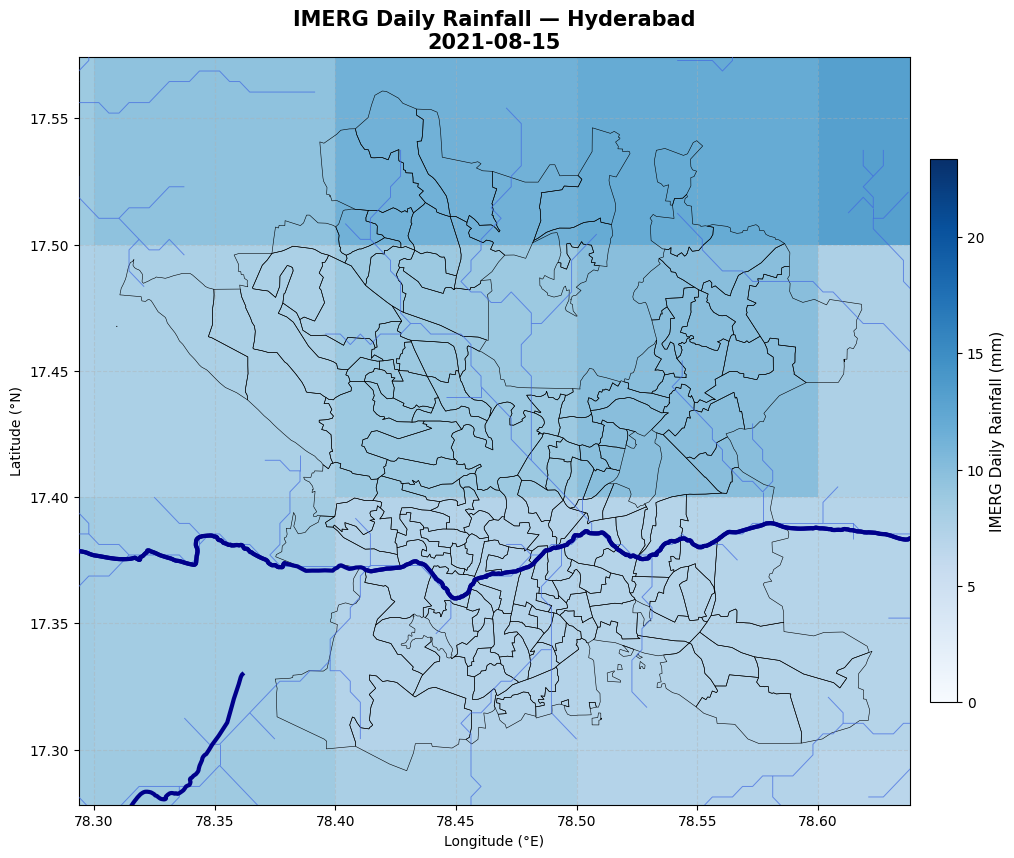

In [15]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# LOAD IMERG DATA
# ============================================================

imerg = pd.read_parquet(
    "/home/sandeep/imerg_hyderabad_2001_2024.parquet"
)

date = "2021-08-15"

rain = imerg[imerg["time"] == date]

# convert to grid
rain_grid = rain.pivot(
    index="lat",
    columns="lon",
    values="precipitation"
)

lats = rain_grid.index.values
lons = rain_grid.columns.values
rain_values = rain_grid.values

# ============================================================
# LOAD GIS LAYERS
# ============================================================

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

rivers = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/hydrorivers_clean.geojson"
).to_crs(epsg=4326)

musi = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/musi.geojson"
).to_crs(epsg=4326)

# ============================================================
# MAP EXTENT
# ============================================================

minx, miny, maxx, maxy = wards.total_bounds
pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)

# ============================================================
# FIGURE
# ============================================================

fig, ax = plt.subplots(figsize=(11,9))

# ------------------------------------------------------------
# 1. RAINFALL GRID
# ------------------------------------------------------------

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=np.nanmax(rain_values)
)

mesh = ax.pcolormesh(
    lons,
    lats,
    rain_values,
    cmap="Blues",
    shading="auto",
    norm=norm,
    zorder=1
)

# ------------------------------------------------------------
# 2. WARD BOUNDARIES
# ------------------------------------------------------------

wards.plot(
    ax=ax,
    facecolor="none",
    edgecolor="black",
    linewidth=0.4,
    zorder=3
)

# ------------------------------------------------------------
# 3. RIVER NETWORK
# ------------------------------------------------------------

rivers.plot(
    ax=ax,
    color="royalblue",
    linewidth=0.7,
    alpha=0.7,
    zorder=4
)

# ------------------------------------------------------------
# 4. MUSI RIVER
# ------------------------------------------------------------

musi.plot(
    ax=ax,
    color="darkblue",
    linewidth=3,
    zorder=5
)

# ------------------------------------------------------------
# COLORBAR
# ------------------------------------------------------------

cbar = plt.colorbar(mesh, ax=ax, shrink=0.65, pad=0.02)

cbar.set_label(
    "IMERG Daily Rainfall (mm)",
    fontsize=11
)

# ------------------------------------------------------------
# AXES
# ------------------------------------------------------------

ax.set_xlim(minx - pad_x, maxx + pad_x)
ax.set_ylim(miny - pad_y, maxy + pad_y)

ax.set_xlabel("Longitude (°E)")
ax.set_ylabel("Latitude (°N)")

ax.grid(True, linestyle="--", alpha=0.4)

ax.set_title(
    f"IMERG Daily Rainfall — Hyderabad\n{date}",
    fontsize=15,
    weight="bold"
)

plt.tight_layout()
plt.show()


In [22]:
imd_series = []

for year in range(2010, 2024):
    fpath = Path(
        f"/vol/sandeep_storage/Files2/catastrophe/imd_rainfall/"
        f"RF25_ind{year}_rfp25.nc"
    )
    
    if not fpath.exists():
        continue

    ds = xr.open_dataset(fpath)

    # Spatial clip
    ds = ds.sel(
        LONGITUDE=slice(minx, maxx),
        LATITUDE=slice(miny, maxy)
    )

    # Basin-mean daily rainfall
    imd_daily = (
        ds["RAINFALL"]
        .mean(dim=["LATITUDE", "LONGITUDE"])
        .to_dataframe()
        .rename(columns={"RAINFALL": "imd_mm"})
    )

    imd_series.append(imd_daily)

imd_daily = pd.concat(imd_series)
imd_daily.index = pd.to_datetime(imd_daily.index)

print("IMD period:", imd_daily.index.min(), "→", imd_daily.index.max())


IMD period: 2010-01-01 00:00:00 → 2023-12-31 00:00:00


In [53]:
# ============================================================
# IMPORTS
# ============================================================

import pandas as pd
import numpy as np
from scipy.interpolate import interp1d

# ============================================================
# LOAD DATA
# ============================================================

# IMERG dataset (0.1°)
imerg_par = pd.read_parquet(
    "/home/sandeep/imerg_hyderabad_2001_2024.parquet"
)

# IMD daily basin rainfall (already computed)
# columns: index=time , imd_mm
# example variable name: imd_daily

# ============================================================
# PREPARE TIME INDEX
# ============================================================

imerg_par["time"] = pd.to_datetime(imerg_par["time"])

# ============================================================
# CREATE IMERG BASIN MEAN SERIES
# (used only for bias estimation)
# ============================================================

imerg_daily = (
    imerg_par
    .groupby("time")["precipitation"]
    .mean()
)

# ============================================================
# ALIGN WITH IMD PERIOD
# ============================================================

df_bias = pd.concat(
    [imerg_daily, imd_daily["imd_mm"]],
    axis=1
)

df_bias.columns = ["imerg_mm", "imd_mm"]

df_bias = df_bias.dropna()

print("Bias correction period:")
print(df_bias.index.min(), "→", df_bias.index.max())

# ============================================================
# COMPUTE QUANTILES
# ============================================================

q = np.linspace(0, 1, 1000)

imerg_q = np.quantile(df_bias["imerg_mm"], q)
imd_q = np.quantile(df_bias["imd_mm"], q)

# ============================================================
# REMOVE DUPLICATE QUANTILES
# (important for rainfall datasets)
# ============================================================

mask = np.diff(imerg_q, prepend=imerg_q[0] - 1) > 0

imerg_q_unique = imerg_q[mask]
imd_q_unique = imd_q[mask]

# ============================================================
# BUILD QUANTILE MAPPING FUNCTION
# ============================================================

bias_map = interp1d(
    imerg_q_unique,
    imd_q_unique,
    bounds_error=False,
    fill_value="extrapolate"
)

# ============================================================
# APPLY BIAS CORRECTION TO FULL IMERG DATASET
# ============================================================

imerg_par["precip_bc"] = bias_map(
    imerg_par["precipitation"].values
)

# Ensure rainfall cannot be negative
imerg_par["precip_bc"] = imerg_par["precip_bc"].clip(lower=0)

# ============================================================
# SAVE BIAS CORRECTED DATA
# ============================================================

out_path = "/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet"

imerg_par.to_parquet(
    out_path,
    index=False
)

print("Bias corrected IMERG saved to:")
print(out_path)

# ============================================================
# QUICK EXTREME CHECK
# ============================================================

print("\nExtreme rainfall check:")

print(
    "IMERG P99:",
    np.percentile(df_bias["imerg_mm"], 99)
)

print(
    "IMD P99:",
    np.percentile(df_bias["imd_mm"], 99)
)

print(
    "BC IMERG P99:",
    np.percentile(
        bias_map(df_bias["imerg_mm"]),
        99
    )
)


Bias correction period:
2010-01-01 00:00:00 → 2023-12-31 00:00:00
Bias corrected IMERG saved to:
/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet

Extreme rainfall check:
IMERG P99: 27.032960815429696
IMD P99: 39.606503448486336
BC IMERG P99: 39.604664140184326


In [54]:
p995 = np.percentile(imerg_par["precip_bc"], 99.5)

imerg_par["precip_bc"] = np.clip(
    imerg_par["precip_bc"],
    0,
    p995
)


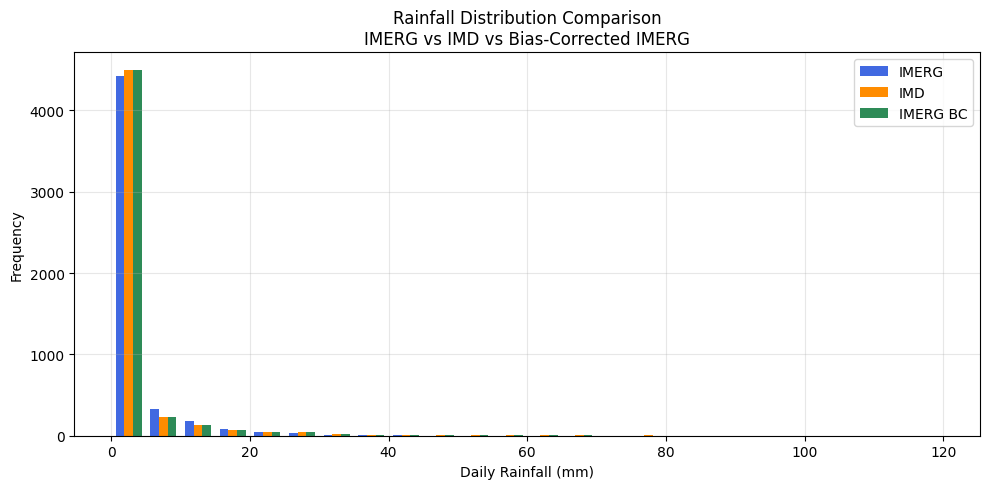

In [55]:
import numpy as np
import matplotlib.pyplot as plt

# Convert to arrays
imerg = df_bias["imerg_mm"].values
imd = df_bias["imd_mm"].values
bc = bias_map(df_bias["imerg_mm"].values)

# Define rainfall bins
bins = np.linspace(0, 120, 25)

# Histogram counts
hist_imerg, _ = np.histogram(imerg, bins=bins)
hist_imd, _ = np.histogram(imd, bins=bins)
hist_bc, _ = np.histogram(bc, bins=bins)

# Bin centers
bin_centers = (bins[:-1] + bins[1:]) / 2

# Bar width
width = (bins[1] - bins[0]) / 4

plt.figure(figsize=(10,5))

plt.bar(
    bin_centers - width,
    hist_imerg,
    width=width,
    color="royalblue",
    label="IMERG"
)

plt.bar(
    bin_centers,
    hist_imd,
    width=width,
    color="darkorange",
    label="IMD"
)

plt.bar(
    bin_centers + width,
    hist_bc,
    width=width,
    color="seagreen",
    label="IMERG BC"
)

plt.xlabel("Daily Rainfall (mm)")
plt.ylabel("Frequency")

plt.title(
    "Rainfall Distribution Comparison\n"
    "IMERG vs IMD vs Bias-Corrected IMERG"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()


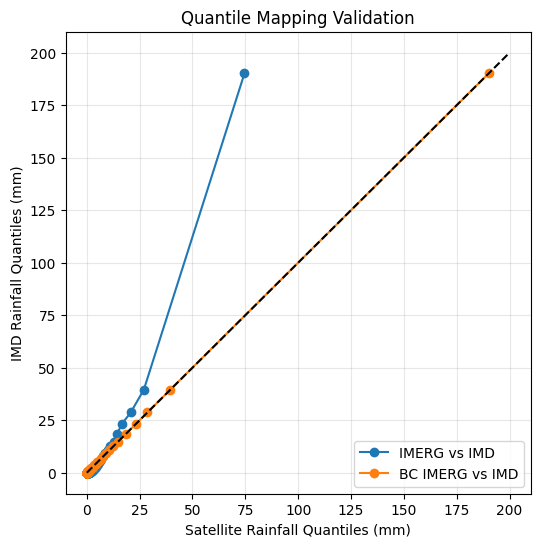

In [56]:
import numpy as np

q = np.linspace(0,1,100)

imerg_q = np.quantile(df_bias["imerg_mm"], q)
imd_q = np.quantile(df_bias["imd_mm"], q)
bc_q = np.quantile(bias_map(df_bias["imerg_mm"]), q)

plt.figure(figsize=(6,6))

plt.plot(imerg_q, imd_q, label="IMERG vs IMD", marker="o")
plt.plot(bc_q, imd_q, label="BC IMERG vs IMD", marker="o")

plt.plot([0,200],[0,200],"k--")

plt.xlabel("Satellite Rainfall Quantiles (mm)")
plt.ylabel("IMD Rainfall Quantiles (mm)")

plt.title("Quantile Mapping Validation")
plt.legend()
plt.grid(alpha=0.3)

plt.show()


In [61]:
wet_imerg = (df_bias["imerg_mm"] > 1).mean()
wet_imd = (df_bias["imd_mm"] > 1).mean()
wet_bc = (bias_map(df_bias["imerg_mm"]) > 1).mean()

print("Wet day frequency")
print("IMERG:",wet_imerg)
print("IMD:",wet_imd)
print("BC:",wet_bc)


Wet day frequency
IMERG: 0.3096029728143947
IMD: 0.2098572266770976
BC: 0.20966164678271074


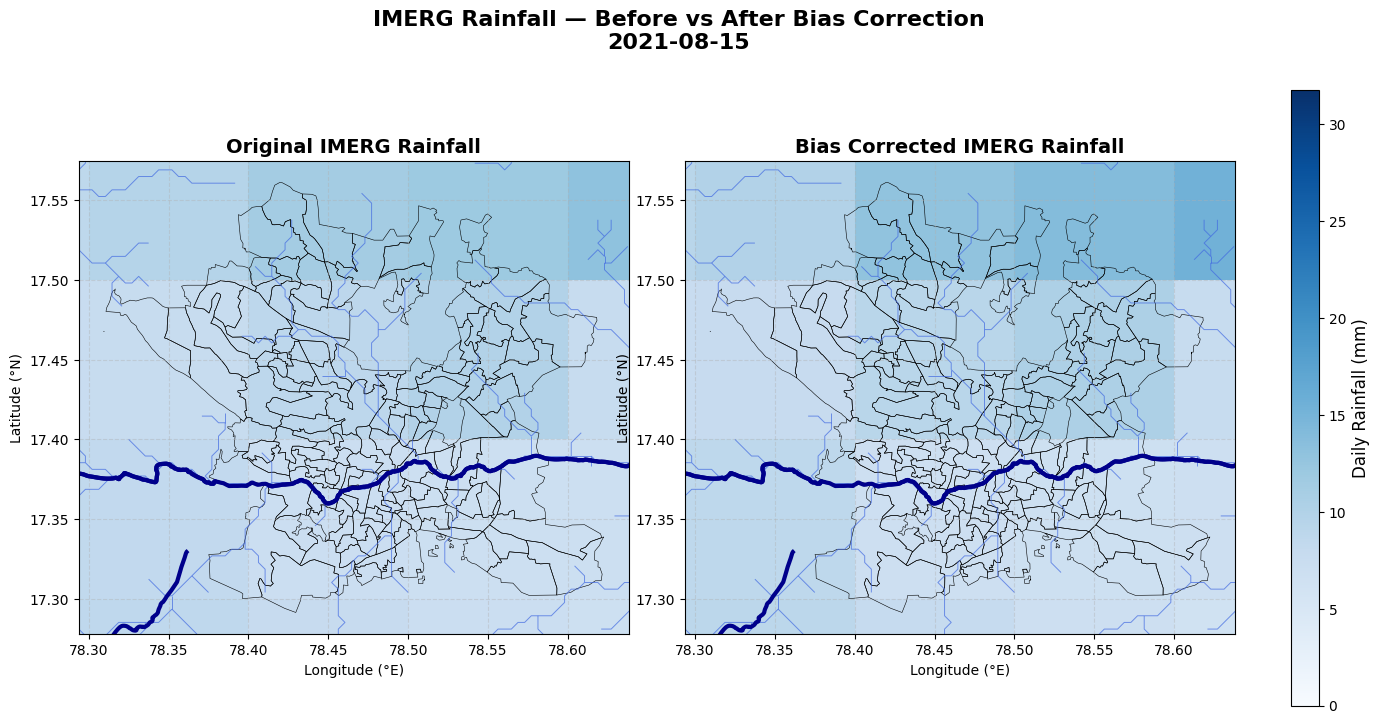

In [1]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# LOAD DATA
# ============================================================

imerg = pd.read_parquet(
    "/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet"
)

date = "2021-08-15"

rain = imerg[imerg["time"] == date]

# ------------------------------------------------------------
# GRID ORIGINAL
# ------------------------------------------------------------

rain_grid_orig = rain.pivot(
    index="lat",
    columns="lon",
    values="precipitation"
)

# ------------------------------------------------------------
# GRID BIAS CORRECTED
# ------------------------------------------------------------

rain_grid_bc = rain.pivot(
    index="lat",
    columns="lon",
    values="precip_bc"
)

lats = rain_grid_orig.index.values
lons = rain_grid_orig.columns.values

orig_values = rain_grid_orig.values
bc_values = rain_grid_bc.values

# ============================================================
# LOAD GIS
# ============================================================

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

rivers = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/hydrorivers_clean.geojson"
).to_crs(epsg=4326)

musi = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/musi.geojson"
).to_crs(epsg=4326)

# ============================================================
# MAP EXTENT
# ============================================================

minx, miny, maxx, maxy = wards.total_bounds

pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)

# ============================================================
# SHARED COLOR SCALE
# ============================================================

vmax = max(
    np.nanmax(orig_values),
    np.nanmax(bc_values)
)

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=vmax
)

# ============================================================
# FIGURE LAYOUT (EQUAL HEIGHT + COLORBAR)
# ============================================================

fig = plt.figure(figsize=(16,8))

gs = GridSpec(
    1, 3,
    width_ratios=[1, 1, 0.05],
    wspace=0.15
)

ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
cax = fig.add_subplot(gs[2])

# ============================================================
# ORIGINAL IMERG MAP
# ============================================================

mesh1 = ax1.pcolormesh(
    lons,
    lats,
    orig_values,
    cmap="Blues",
    shading="auto",
    norm=norm,
    zorder=1
)

wards.plot(ax=ax1, facecolor="none", edgecolor="black", linewidth=0.4)
rivers.plot(ax=ax1, color="royalblue", linewidth=0.7, alpha=0.7)
musi.plot(ax=ax1, color="darkblue", linewidth=3)

ax1.set_title(
    "Original IMERG Rainfall",
    fontsize=14,
    weight="bold"
)

# ============================================================
# BIAS CORRECTED MAP
# ============================================================

mesh2 = ax2.pcolormesh(
    lons,
    lats,
    bc_values,
    cmap="Blues",
    shading="auto",
    norm=norm,
    zorder=1
)

wards.plot(ax=ax2, facecolor="none", edgecolor="black", linewidth=0.4)
rivers.plot(ax=ax2, color="royalblue", linewidth=0.7, alpha=0.7)
musi.plot(ax=ax2, color="darkblue", linewidth=3)

ax2.set_title(
    "Bias Corrected IMERG Rainfall",
    fontsize=14,
    weight="bold"
)

# ============================================================
# AXIS FORMAT
# ============================================================

for ax in [ax1, ax2]:

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    ax.grid(True, linestyle="--", alpha=0.4)

    # Keep geographic aspect ratio correct
    ax.set_aspect("equal")

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(
    mesh2,
    cax=cax
)

cbar.set_label(
    "Daily Rainfall (mm)",
    fontsize=12
)

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    f"IMERG Rainfall — Before vs After Bias Correction\n{date}",
    fontsize=16,
    weight="bold"
)

plt.show()


Total records: 1753200
Total daily observations: 8766
After QC observations: 8763

Rainfall percentiles (mm)
[  7.68340523  16.47099566  23.6702664   44.83958486  63.98882218
 103.29007254]

Maximum rainfall: 207.82999828552266


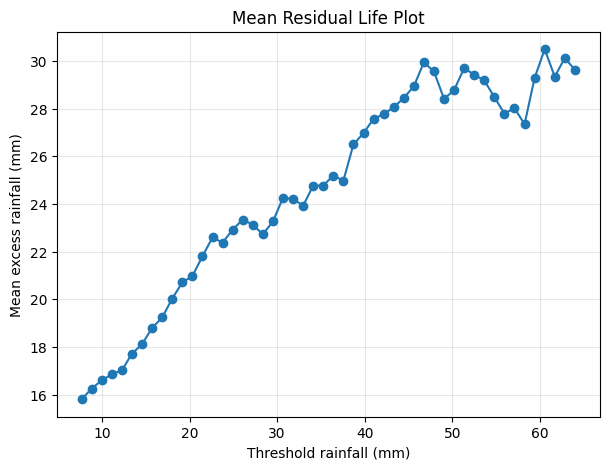


Selected threshold: 30 mm
Storm events: 120

GPD Parameters
------------------
Shape (xi): 0.13858484650586758
Scale (sigma): 25.142889116004397

Data duration: 24.008219178082193 years
Storm exceedances per year: 4.99828825744608

EVT Return Levels (POT-GPD)
--------------------------------
2 year rainfall: 98.18501080187743 mm
5 year rainfall: 131.98205275575134 mm
10 year rainfall: 160.5566025034741 mm
25 year rainfall: 202.79868706338684 mm
50 year rainfall: 238.51330813442948 mm
100 year rainfall: 277.8288478911134 mm


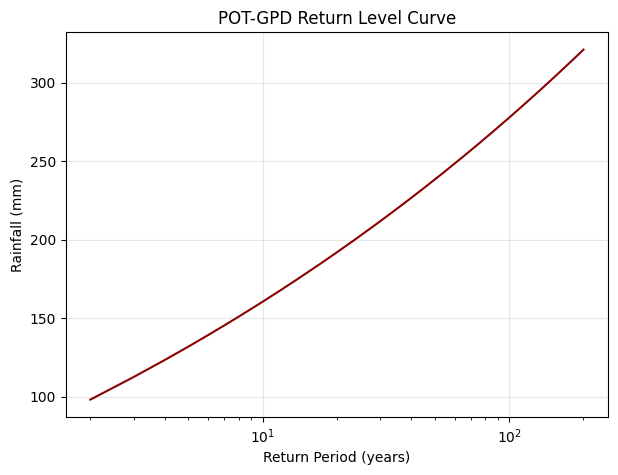

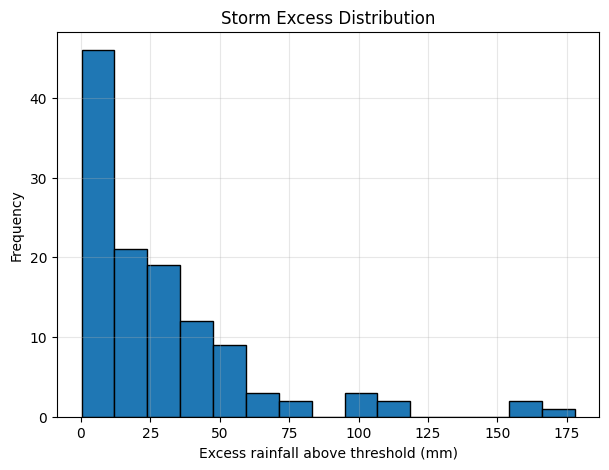

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genpareto

# ---------------------------------------------------
# 1. LOAD DATA
# ---------------------------------------------------

imerg = pd.read_parquet(
"/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet"
)

imerg["time"] = pd.to_datetime(imerg["time"])

print("Total records:", len(imerg))

# ---------------------------------------------------
# 2. BASIN DAILY MEAN RAINFALL
# ---------------------------------------------------

rain_daily = (
    imerg
    .groupby("time")["precip_bc"]
    .mean()
)

print("Total daily observations:", len(rain_daily))

# ---------------------------------------------------
# 3. QUALITY CONTROL (REMOVE SATELLITE SPIKES)
# ---------------------------------------------------

rain_daily = rain_daily[rain_daily < 250]

print("After QC observations:", len(rain_daily))

# ---------------------------------------------------
# 4. BASIC RAINFALL DIAGNOSTICS
# ---------------------------------------------------

print("\nRainfall percentiles (mm)")
print(np.percentile(rain_daily,[90,95,97,99,99.5,99.9]))

print("\nMaximum rainfall:", rain_daily.max())

# convert to numpy
rain_daily = rain_daily.values

# ---------------------------------------------------
# 5. MEAN RESIDUAL LIFE (MRL) PLOT
# ---------------------------------------------------

thresholds = np.linspace(
    np.percentile(rain_daily,90),
    np.percentile(rain_daily,99.5),
    50
)

mean_excess = []

for u in thresholds:

    exceed = rain_daily[rain_daily > u]

    if len(exceed) > 0:

        excess = exceed - u
        mean_excess.append(np.mean(excess))

    else:

        mean_excess.append(np.nan)

plt.figure(figsize=(7,5))

plt.plot(
    thresholds,
    mean_excess,
    marker="o"
)

plt.xlabel("Threshold rainfall (mm)")
plt.ylabel("Mean excess rainfall (mm)")
plt.title("Mean Residual Life Plot")

plt.grid(alpha=0.3)

plt.show()

# ---------------------------------------------------
# 6. SELECT THRESHOLD
# ---------------------------------------------------

u = 30

print("\nSelected threshold:",u,"mm")

# ---------------------------------------------------
# 7. STORM DECLUSTERING
# ---------------------------------------------------

rain_series = pd.Series(rain_daily)

exceed = rain_series[rain_series > u]

run = 3   # storm window (days)

clusters = []

current_cluster = [exceed.index[0]]

for i in range(1,len(exceed)):

    if exceed.index[i] - exceed.index[i-1] <= run:

        current_cluster.append(exceed.index[i])

    else:

        clusters.append(current_cluster)
        current_cluster = [exceed.index[i]]

clusters.append(current_cluster)

# storm maxima
cluster_max = []

for c in clusters:

    cluster_max.append(rain_series.loc[c].max())

cluster_max = np.array(cluster_max)

print("Storm events:",len(cluster_max))

# ---------------------------------------------------
# 8. GPD FIT
# ---------------------------------------------------

excess = cluster_max - u

shape,loc,scale = genpareto.fit(excess)

print("\nGPD Parameters")
print("------------------")
print("Shape (xi):",shape)
print("Scale (sigma):",scale)

# ---------------------------------------------------
# 9. EXCEEDANCE RATE
# ---------------------------------------------------

years = len(rain_daily)/365

lam = len(cluster_max)/years

print("\nData duration:",years,"years")
print("Storm exceedances per year:",lam)

# ---------------------------------------------------
# 10. RETURN LEVEL FUNCTION
# ---------------------------------------------------

def return_level(T):

    return u + (scale/shape)*((lam*T)**shape - 1)

# ---------------------------------------------------
# 11. IMPORTANT RETURN PERIODS
# ---------------------------------------------------

periods = [2,5,10,25,50,100]

print("\nEVT Return Levels (POT-GPD)")
print("--------------------------------")

for T in periods:

    print(T,"year rainfall:",return_level(T),"mm")

# ---------------------------------------------------
# 12. RETURN LEVEL CURVE
# ---------------------------------------------------

Ts = np.linspace(2,200,200)

levels = [return_level(T) for T in Ts]

plt.figure(figsize=(7,5))

plt.plot(
    Ts,
    levels,
    color="darkred"
)

plt.xscale("log")

plt.xlabel("Return Period (years)")
plt.ylabel("Rainfall (mm)")
plt.title("POT-GPD Return Level Curve")

plt.grid(alpha=0.3)

plt.show()

# ---------------------------------------------------
# 13. HISTOGRAM OF STORM EXCESSES
# ---------------------------------------------------

plt.figure(figsize=(7,5))

plt.hist(
    excess,
    bins=15,
    edgecolor="black"
)

plt.xlabel("Excess rainfall above threshold (mm)")
plt.ylabel("Frequency")
plt.title("Storm Excess Distribution")

plt.grid(alpha=0.3)

plt.show()


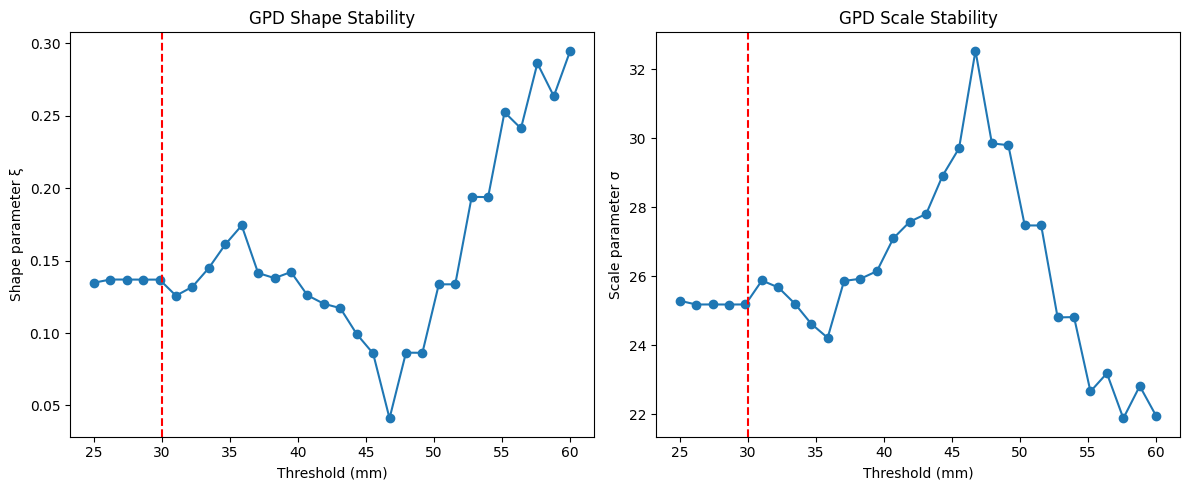

In [41]:
# ---------------------------------------------------
# PARAMETER STABILITY PLOT
# ---------------------------------------------------

threshold_range = np.linspace(25,60,30)

xi_vals = []
sigma_vals = []
counts = []

for thr in threshold_range:

    exc = cluster_max[cluster_max > thr] - thr

    if len(exc) > 20:  # minimum sample size

        xi,loc,sigma = genpareto.fit(exc)

        xi_vals.append(xi)
        sigma_vals.append(sigma)
        counts.append(len(exc))

    else:

        xi_vals.append(np.nan)
        sigma_vals.append(np.nan)
        counts.append(len(exc))


plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(threshold_range,xi_vals,marker="o")
plt.axvline(u,color="red",linestyle="--")
plt.xlabel("Threshold (mm)")
plt.ylabel("Shape parameter ξ")
plt.title("GPD Shape Stability")

plt.subplot(1,2,2)
plt.plot(threshold_range,sigma_vals,marker="o")
plt.axvline(u,color="red",linestyle="--")
plt.xlabel("Threshold (mm)")
plt.ylabel("Scale parameter σ")
plt.title("GPD Scale Stability")

plt.tight_layout()
plt.show()


In [42]:
# ---------------------------------------------------
# RETURN LEVEL CONFIDENCE INTERVALS
# ---------------------------------------------------

n_boot = 1000

boot_levels = []

for i in range(n_boot):

    sample = np.random.choice(excess,len(excess),replace=True)

    xi,loc,sigma = genpareto.fit(sample)

    def rl(T):
        return u + (sigma/xi)*((lam*T)**xi - 1)

    boot_levels.append([rl(T) for T in periods])

boot_levels = np.array(boot_levels)

lower = np.percentile(boot_levels,5,axis=0)
upper = np.percentile(boot_levels,95,axis=0)

print("\nReturn Level Confidence Intervals (90%)")
print("-----------------------------------------")

for i,T in enumerate(periods):

    print(
        f"{T}-yr: {return_level(T):.1f} mm "
        f"[{lower[i]:.1f} – {upper[i]:.1f}]"
    )



Return Level Confidence Intervals (90%)
-----------------------------------------
2-yr: 98.2 mm [87.1 – 110.2]
5-yr: 132.0 mm [111.5 – 154.0]
10-yr: 160.6 mm [129.5 – 198.0]
25-yr: 202.8 mm [152.2 – 273.6]
50-yr: 238.5 mm [170.4 – 344.4]
100-yr: 277.8 mm [187.2 – 428.6]


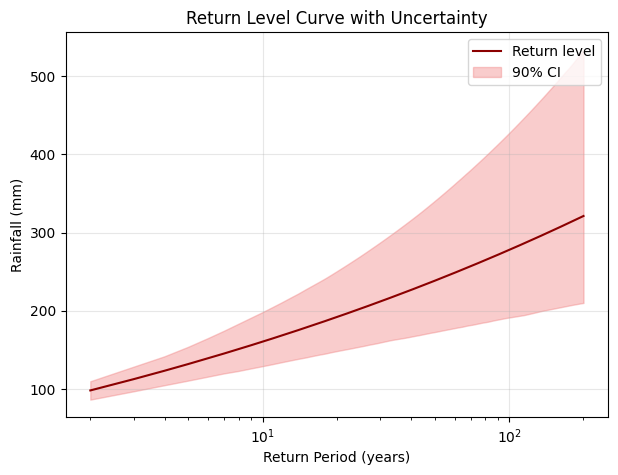

In [43]:
# ---------------------------------------------------
# RETURN LEVEL CURVE WITH UNCERTAINTY
# ---------------------------------------------------

boot_curve = []

for i in range(n_boot):

    sample = np.random.choice(excess,len(excess),replace=True)

    xi,loc,sigma = genpareto.fit(sample)

    def rl(T):
        return u + (sigma/xi)*((lam*T)**xi - 1)

    boot_curve.append([rl(t) for t in Ts])

boot_curve = np.array(boot_curve)

lower_curve = np.percentile(boot_curve,5,axis=0)
upper_curve = np.percentile(boot_curve,95,axis=0)

plt.figure(figsize=(7,5))

plt.plot(Ts,levels,color="darkred",label="Return level")

plt.fill_between(
    Ts,
    lower_curve,
    upper_curve,
    color="lightcoral",
    alpha=0.4,
    label="90% CI"
)

plt.xscale("log")

plt.xlabel("Return Period (years)")
plt.ylabel("Rainfall (mm)")
plt.title("Return Level Curve with Uncertainty")

plt.legend()
plt.grid(alpha=0.3)

plt.show()


Annual maxima count: 24

GEV parameters
shape (scipy): -0.3046818593910494
location: 76.70395529884885
scale: 25.79805557787381

EVT shape ξ = 0.3046818593910494

Return levels
2 yr: 86.70742571463006
5 yr: 125.75755599236544
10 yr: 160.1105521350992
25 yr: 216.40748844513587
50 yr: 270.03603490656894
100 yr: 335.9378155482501


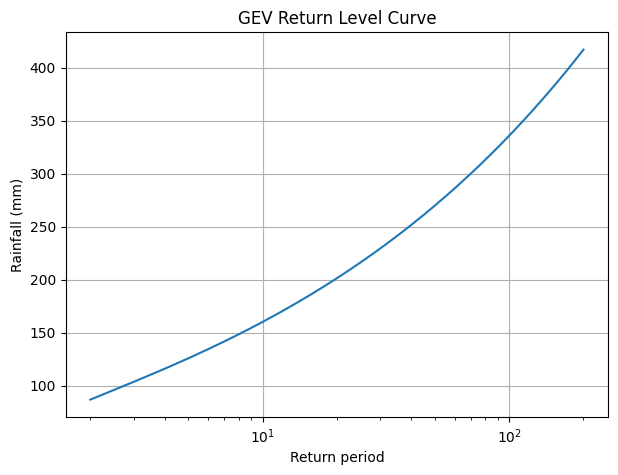

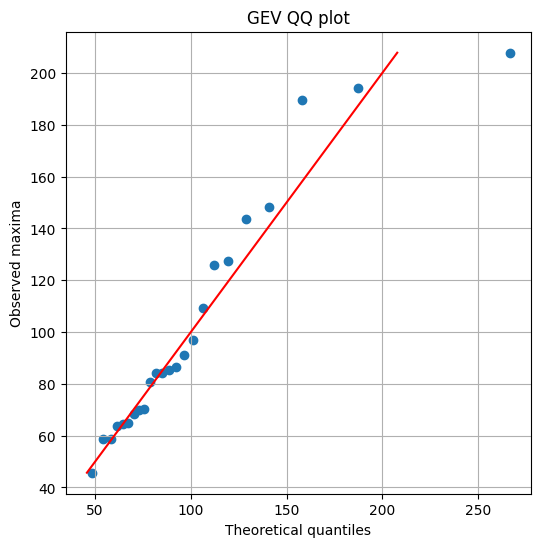

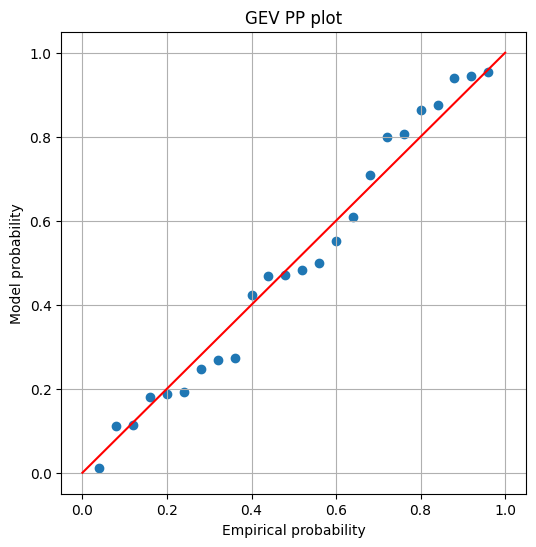

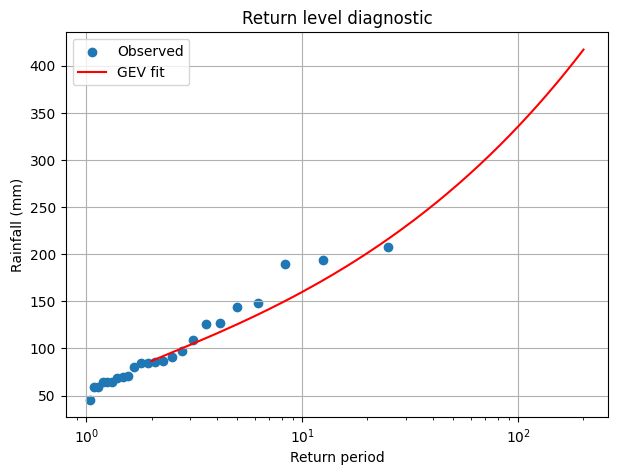

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import genextreme

# ---------------------------------------------------
# LOAD DATA
# ---------------------------------------------------

imerg = pd.read_parquet(
"/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet"
)

imerg["time"] = pd.to_datetime(imerg["time"])

# ---------------------------------------------------
# DAILY BASIN MEAN
# ---------------------------------------------------

rain_daily = (
    imerg.groupby("time")["precip_bc"].mean()
)

rain_daily = rain_daily[rain_daily < 250]

# ---------------------------------------------------
# ANNUAL MAXIMA
# ---------------------------------------------------

rain_df = rain_daily.reset_index()
rain_df["year"] = rain_df["time"].dt.year

annual_max = rain_df.groupby("year")["precip_bc"].max()

data = annual_max.values

n = len(data)

print("Annual maxima count:", n)

# ---------------------------------------------------
# FIT GEV
# ---------------------------------------------------

shape, loc, scale = genextreme.fit(data)

print("\nGEV parameters")
print("shape (scipy):", shape)
print("location:", loc)
print("scale:", scale)

print("\nEVT shape ξ =", -shape)

# ---------------------------------------------------
# RETURN LEVEL FUNCTION
# ---------------------------------------------------

def gev_return(T):

    p = 1 - 1/T
    return genextreme.ppf(p, shape, loc=loc, scale=scale)

# ---------------------------------------------------
# RETURN LEVELS
# ---------------------------------------------------

periods = [2,5,10,25,50,100]

print("\nReturn levels")

for T in periods:
    print(T, "yr:", gev_return(T))

# ---------------------------------------------------
# RETURN LEVEL CURVE
# ---------------------------------------------------

Ts = np.linspace(2,200,200)
levels = [gev_return(T) for T in Ts]

plt.figure(figsize=(7,5))
plt.plot(Ts,levels)
plt.xscale("log")
plt.xlabel("Return period")
plt.ylabel("Rainfall (mm)")
plt.title("GEV Return Level Curve")
plt.grid(True)
plt.show()

# ---------------------------------------------------
# QQ PLOT
# ---------------------------------------------------

sorted_data = np.sort(data)

p = (np.arange(1,n+1)-0.5)/n
theoretical = genextreme.ppf(p,shape,loc=loc,scale=scale)

plt.figure(figsize=(6,6))
plt.scatter(theoretical,sorted_data)
plt.plot([min(sorted_data),max(sorted_data)],
         [min(sorted_data),max(sorted_data)],'r')
plt.xlabel("Theoretical quantiles")
plt.ylabel("Observed maxima")
plt.title("GEV QQ plot")
plt.grid(True)
plt.show()

# ---------------------------------------------------
# PP PLOT
# ---------------------------------------------------

emp_cdf = (np.arange(1,n+1))/(n+1)
model_cdf = genextreme.cdf(sorted_data,shape,loc=loc,scale=scale)

plt.figure(figsize=(6,6))
plt.scatter(emp_cdf,model_cdf)
plt.plot([0,1],[0,1],'r')
plt.xlabel("Empirical probability")
plt.ylabel("Model probability")
plt.title("GEV PP plot")
plt.grid(True)
plt.show()

# ---------------------------------------------------
# RETURN LEVEL DIAGNOSTIC
# ---------------------------------------------------

rank = np.arange(1,n+1)
empirical_T = 1/(1-rank/(n+1))

plt.figure(figsize=(7,5))
plt.scatter(empirical_T,sorted_data,label="Observed")
plt.plot(Ts,levels,'r',label="GEV fit")
plt.xscale("log")
plt.xlabel("Return period")
plt.ylabel("Rainfall (mm)")
plt.title("Return level diagnostic")
plt.legend()
plt.grid(True)
plt.show()


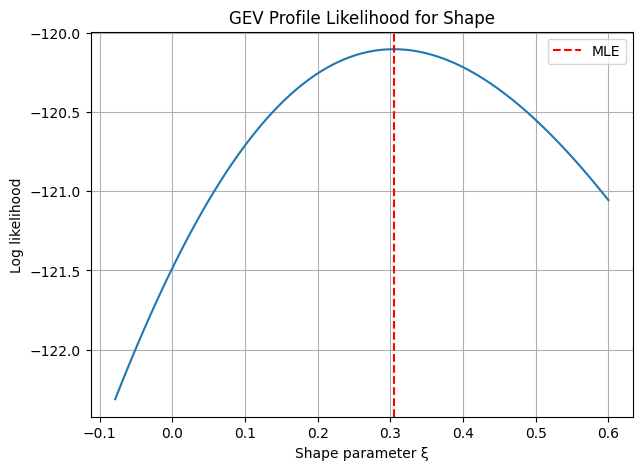

In [51]:
# ---------------------------------------------------
# PROFILE LIKELIHOOD FOR SHAPE PARAMETER
# ---------------------------------------------------

from scipy.stats import genextreme

data = annual_max.values
n = len(data)

xi_range = np.linspace(-0.2,0.6,100)

loglik = []

for xi in xi_range:

    # scipy uses c = -xi
    c = -xi
    
    try:
        loc,scale = genextreme.fit(data,f0=c)[1:]
        ll = np.sum(genextreme.logpdf(data,c,loc=loc,scale=scale))
    except:
        ll = np.nan
        
    loglik.append(ll)

loglik = np.array(loglik)

plt.figure(figsize=(7,5))
plt.plot(xi_range,loglik)
plt.axvline(-shape,color='red',linestyle='--',label='MLE')
plt.xlabel("Shape parameter ξ")
plt.ylabel("Log likelihood")
plt.title("GEV Profile Likelihood for Shape")
plt.legend()
plt.grid()
plt.show()


In [53]:
# ---------------------------------------------------
# STABLE GEV BOOTSTRAP CI
# ---------------------------------------------------

PMP = 450

boot_levels = []

for i in range(2000):

    sample = np.random.choice(data,len(data),replace=True)

    try:
        c,loc_b,scale_b = genextreme.fit(sample)

        xi = -c

        # filter unrealistic fits
        if xi < -0.3 or xi > 0.4:
            continue

        levels = []

        for T in periods:

            rl = genextreme.ppf(1-1/T,c,loc=loc_b,scale=scale_b)

            if rl > PMP:
                rl = PMP

            levels.append(rl)

        boot_levels.append(levels)

    except:
        continue


boot_levels = np.array(boot_levels)

lower = np.percentile(boot_levels,5,axis=0)
upper = np.percentile(boot_levels,95,axis=0)

print("\nGEV Return Level 90% CI")

for i,T in enumerate(periods):

    print(
        f"{T}-yr: {gev_return(T):.1f} mm "
        f"[{lower[i]:.1f} – {upper[i]:.1f}]"
    )



GEV Return Level 90% CI
2-yr: 85.5 mm [75.5 – 104.2]
5-yr: 127.6 mm [100.6 – 150.6]
10-yr: 164.7 mm [121.5 – 189.2]
25-yr: 225.4 mm [148.5 – 253.4]
50-yr: 283.2 mm [171.0 – 322.0]
100-yr: 354.2 mm [195.0 – 410.4]


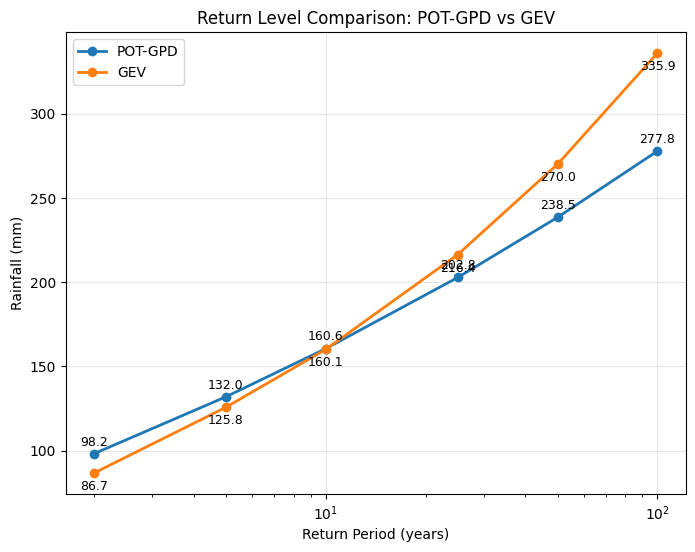

In [59]:
import matplotlib.pyplot as plt
import numpy as np

# return periods
T = np.array([2,5,10,25,50,100])

# POT values
pot = np.array([
98.18501080187743,
131.98205275575134,
160.5566025034741,
202.79868706338684,
238.51330813442948,
277.8288478911134
])

# GEV values
gev = np.array([
86.70742571463006,
125.75755599236544,
160.1105521350992,
216.40748844513587,
270.03603490656894,
335.9378155482501
])

plt.figure(figsize=(8,6))

plt.plot(T, pot, marker='o', linewidth=2, label="POT-GPD")
plt.plot(T, gev, marker='o', linewidth=2, label="GEV")

for i in range(len(T)):
    plt.text(T[i], pot[i]+5, f"{pot[i]:.1f}", ha='center', fontsize=9)
    plt.text(T[i], gev[i]-10, f"{gev[i]:.1f}", ha='center', fontsize=9)

plt.xscale("log")

plt.xlabel("Return Period (years)")
plt.ylabel("Rainfall (mm)")
plt.title("Return Level Comparison: POT-GPD vs GEV")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


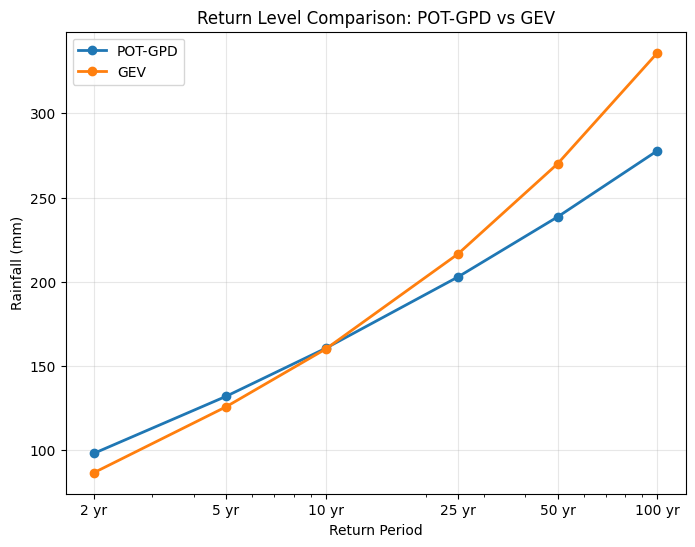

In [61]:
import matplotlib.pyplot as plt
import numpy as np

# return periods
T = np.array([2,5,10,25,50,100])

# POT values
pot = np.array([
98.18501080187743,
131.98205275575134,
160.5566025034741,
202.79868706338684,
238.51330813442948,
277.8288478911134
])

# GEV values
gev = np.array([
86.70742571463006,
125.75755599236544,
160.1105521350992,
216.40748844513587,
270.03603490656894,
335.9378155482501
])

plt.figure(figsize=(8,6))

plt.plot(T, pot, marker='o', linewidth=2, label="POT-GPD")
plt.plot(T, gev, marker='o', linewidth=2, label="GEV")

# annotate rainfall values
#for i in range(len(T)):
 #   plt.text(T[i], pot[i]+6, f"{pot[i]:.1f} mm", ha='center', fontsize=9)
  #  plt.text(T[i], gev[i]-12, f"{gev[i]:.1f} mm", ha='center', fontsize=9)

# log axis
plt.xscale("log")

# explicitly show year ticks
plt.xticks(T, [f"{t} yr" for t in T])

plt.xlabel("Return Period")
plt.ylabel("Rainfall (mm)")
plt.title("Return Level Comparison: POT-GPD vs GEV")

plt.grid(alpha=0.3)
plt.legend()

plt.show()


---

#### ward level EVT

In [81]:
import pandas as pd
import numpy as np
import geopandas as gpd
from scipy.stats import genpareto
from shapely.geometry import Point
from tqdm import tqdm

# ============================================================
# LOAD DATA
# ============================================================

imerg = pd.read_parquet(
"/home/sandeep/imerg_hyderabad_2001_2024_bias_corrected.parquet"
)

imerg["time"] = pd.to_datetime(imerg["time"])

# remove unrealistic rainfall spikes
imerg = imerg[imerg["precip_bc"] < 250]

# ------------------------------------------------------------
# LOAD WARDS
# ------------------------------------------------------------

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

# ============================================================
# GRID CELLS
# ============================================================

grid_cells = imerg[["lat","lon"]].drop_duplicates()

results = []

# ============================================================
# EVT SETTINGS
# ============================================================

threshold_quantile = 0.95
run_window = 3
return_periods = [10,25,50,100]

# ============================================================
# LOOP OVER GRID CELLS
# ============================================================

for _, cell in tqdm(grid_cells.iterrows(), total=len(grid_cells)):

    lat = cell["lat"]
    lon = cell["lon"]

    df = imerg[(imerg["lat"] == lat) & (imerg["lon"] == lon)].copy()

    df = df.sort_values("time")

    rain_series = df.set_index("time")["precip_bc"]

    if len(rain_series) < 365:
        continue

    # --------------------------------------------------------
    # THRESHOLD
    # --------------------------------------------------------

    u = rain_series.quantile(threshold_quantile)

    exceed = rain_series[rain_series > u]

    if len(exceed) < 20:
        continue

    # --------------------------------------------------------
    # DECLUSTERING
    # --------------------------------------------------------

    clusters = []
    current_cluster = [exceed.index[0]]

    for i in range(1, len(exceed)):

        dt = (exceed.index[i] - exceed.index[i-1]).days

        if dt <= run_window:
            current_cluster.append(exceed.index[i])
        else:
            clusters.append(current_cluster)
            current_cluster = [exceed.index[i]]

    clusters.append(current_cluster)

    cluster_max = [
        rain_series.loc[c].max()
        for c in clusters
    ]

    cluster_max = np.array(cluster_max)

    excess = cluster_max - u

    if len(excess) < 15:
        continue

    # --------------------------------------------------------
    # GPD FIT
    # --------------------------------------------------------

    try:
        shape, loc, scale = genpareto.fit(excess)
    except:
        continue

    # filter unstable fits
    if np.isnan(shape) or np.isnan(scale):
        continue

    if scale <= 0:
        continue

    if shape < -0.5 or shape > 0.8:
        continue

    years = len(rain_series) / 365
    lam = len(cluster_max) / years

    # --------------------------------------------------------
    # RETURN LEVEL FUNCTION
    # --------------------------------------------------------

    def return_level(T):

        if abs(shape) < 1e-6:
            return u + scale * np.log(lam * T)

        return u + (scale / shape) * ((lam * T) ** shape - 1)

    # --------------------------------------------------------
    # STORE
    # --------------------------------------------------------

    row = {
        "lat": lat,
        "lon": lon,
        "threshold": u,
        "shape": shape,
        "scale": scale,
        "storms": len(cluster_max)
    }

    for T in return_periods:
        row[f"rl_{T}"] = return_level(T)

    results.append(row)

# ============================================================
# GRID EVT RESULTS
# ============================================================

grid_evt = pd.DataFrame(results)

geometry = [
    Point(xy) for xy in zip(grid_evt["lon"], grid_evt["lat"])
]

grid_gdf = gpd.GeoDataFrame(
    grid_evt,
    geometry=geometry,
    crs="EPSG:4326"
)

# ------------------------------------------------------------
# SAVE GRID EVT (important for diagnostics)
# ------------------------------------------------------------

grid_gdf.to_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_grid_evt.geojson",
driver="GeoJSON"
)

# ============================================================
# SPATIAL JOIN TO WARDS
# ============================================================

joined = gpd.sjoin(
    grid_gdf,
    wards,
    predicate="intersects"
)

# ============================================================
# WARD RETURN LEVELS
# ============================================================

ward_evt = joined.groupby("ward_id").agg({

    "rl_10": "mean",
    "rl_25": "mean",
    "rl_50": "mean",
    "rl_100": "mean"

}).reset_index()

wards_evt = wards.merge(
    ward_evt,
    on="ward_id",
    how="left"
)

# ============================================================
# SAVE WARD RESULTS
# ============================================================

wards_evt.to_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_ward_evt_return_levels.geojson",
driver="GeoJSON"
)

print("EVT completed.")
print("Grid results saved.")
print("Ward rainfall return levels saved.")


100%|██████████| 200/200 [00:35<00:00,  5.59it/s]


EVT completed.
Grid results saved.
Ward rainfall return levels saved.


In [82]:
import geopandas as gpd
import matplotlib.pyplot as plt

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_grid_evt.geojson"
)

print(grid_evt.head())


     lat        lon  threshold     shape      scale  storms       rl_10  \
0  16.05  78.050003  15.022007  0.166985  23.069652     242  175.356345   
1  16.15  78.050003  14.767875  0.233828  22.866178     238  203.448157   
2  16.25  78.050003  14.877980  0.259889  22.983440     239  218.787344   
3  16.35  78.050003  15.010673  0.225972  23.179774     232  200.595469   
4  16.45  78.050003  15.668753  0.188318  22.342579     237  178.747773   

        rl_25       rl_50      rl_100             geometry  
0  224.706383  267.389628  315.310538  POINT (78.05 16.05)  
1  271.897000  334.345601  407.782125  POINT (78.05 16.15)  
2  297.392904  370.613675  458.287272  POINT (78.05 16.25)  
3  266.887807  326.991024  397.285647  POINT (78.05 16.35)  
4  231.806095  278.485952  331.674581  POINT (78.05 16.45)  


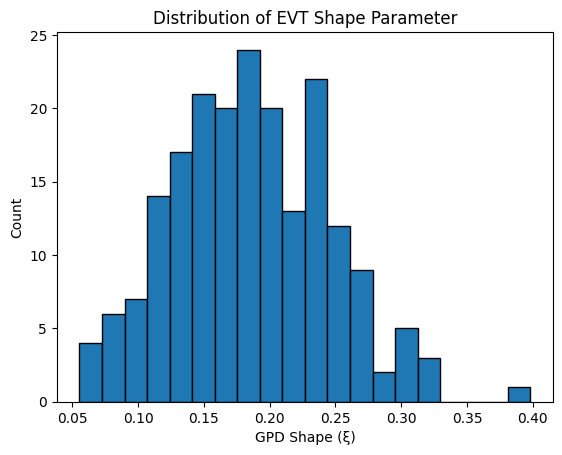

In [83]:
plt.hist(grid_evt["shape"], bins=20, edgecolor="black")
plt.xlabel("GPD Shape (ξ)")
plt.ylabel("Count")
plt.title("Distribution of EVT Shape Parameter")
plt.show()


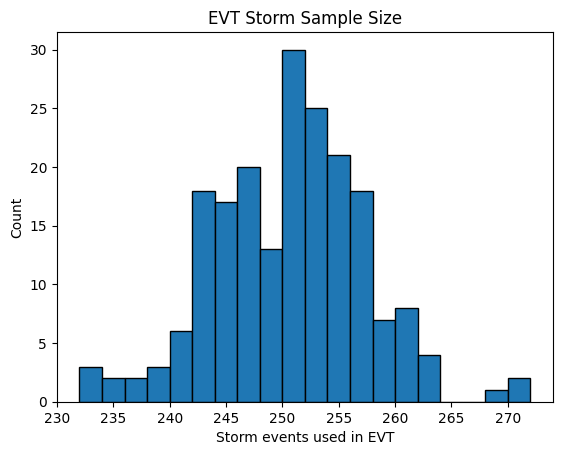

In [84]:
plt.hist(grid_evt["storms"], bins=20, edgecolor="black")
plt.xlabel("Storm events used in EVT")
plt.ylabel("Count")
plt.title("EVT Storm Sample Size")
plt.show()


In [85]:
wards_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_ward_evt_return_levels.geojson"
)

print(wards_evt[["rl_10","rl_25","rl_50","rl_100"]].describe())


            rl_10       rl_25       rl_50      rl_100
count    5.000000    5.000000    5.000000    5.000000
mean   200.998728  255.754981  302.861485  355.520877
std      9.705825   16.308727   23.003027   31.458811
min    187.332782  232.626817  270.177233  310.817221
25%    198.169336  250.660374  295.437572  345.111375
50%    202.411236  257.691742  305.170989  358.154248
75%    202.782209  260.128634  310.067249  366.466100
max    214.298075  277.667338  333.454381  397.055440


In [86]:
bad = wards_evt[
    (wards_evt["rl_10"] > wards_evt["rl_25"]) |
    (wards_evt["rl_25"] > wards_evt["rl_50"]) |
    (wards_evt["rl_50"] > wards_evt["rl_100"])
]

print("Problem wards:")
print(bad)


Problem wards:
Empty GeoDataFrame
Columns: [ward_id, area_km2, centroid_x, centroid_y, road_km, road_density, dist_hospital_m, dist_hospital_km, rl_10, rl_25, rl_50, rl_100, geometry]
Index: []


In [87]:
print(wards_evt["rl_100"].mean())


355.52087660396927


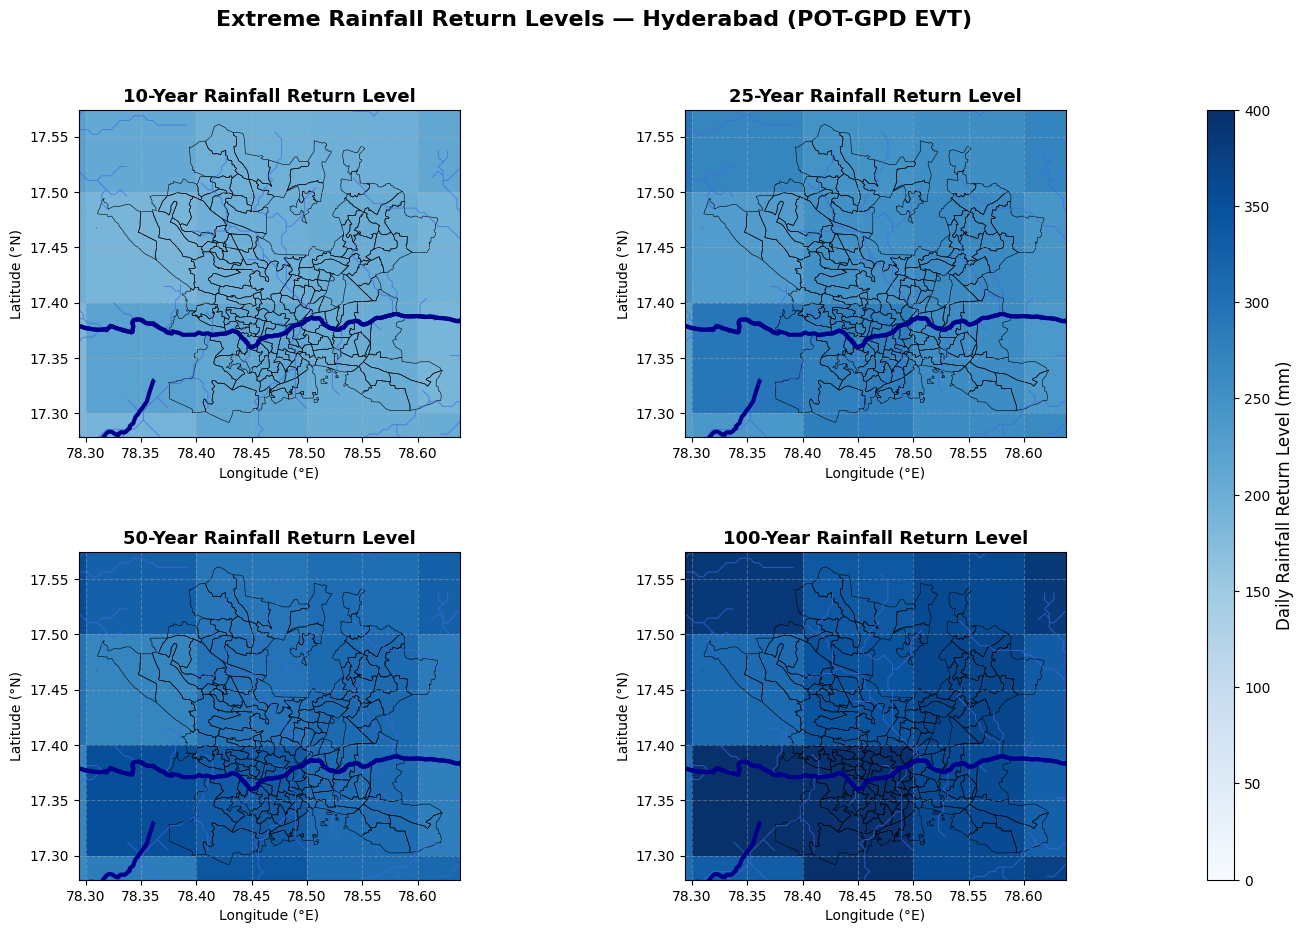

In [88]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# LOAD GRID EVT RESULTS
# ============================================================

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_grid_evt.geojson"
)

# ------------------------------------------------------------
# CREATE GRIDS
# ------------------------------------------------------------

grid_10 = grid_evt.pivot(index="lat", columns="lon", values="rl_10")
grid_25 = grid_evt.pivot(index="lat", columns="lon", values="rl_25")
grid_50 = grid_evt.pivot(index="lat", columns="lon", values="rl_50")
grid_100 = grid_evt.pivot(index="lat", columns="lon", values="rl_100")

lats = grid_10.index.values
lons = grid_10.columns.values

vals10 = grid_10.values
vals25 = grid_25.values
vals50 = grid_50.values
vals100 = grid_100.values

# ============================================================
# LOAD GIS
# ============================================================

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

rivers = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/hydrorivers_clean.geojson"
).to_crs(epsg=4326)

musi = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/musi.geojson"
).to_crs(epsg=4326)

# ============================================================
# MAP EXTENT
# ============================================================

minx, miny, maxx, maxy = wards.total_bounds

pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)

# ============================================================
# COLOR SCALE (LIMITED TO 400 mm)
# ============================================================

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=400
)

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(figsize=(16,10))

gs = GridSpec(
    2, 3,
    width_ratios=[1,1,0.05],
    wspace=0.15,
    hspace=0.35   # increased vertical gap
)

ax1 = fig.add_subplot(gs[0,0])
ax2 = fig.add_subplot(gs[0,1])
ax3 = fig.add_subplot(gs[1,0])
ax4 = fig.add_subplot(gs[1,1])
cax = fig.add_subplot(gs[:,2])

# ============================================================
# PLOT FUNCTION
# ============================================================

def plot_map(ax, values, title):

    mesh = ax.pcolormesh(
        lons,
        lats,
        values,
        cmap="Blues",
        shading="auto",
        norm=norm,
        zorder=1
    )

    wards.plot(ax=ax, facecolor="none", edgecolor="black", linewidth=0.4)
    rivers.plot(ax=ax, color="royalblue", linewidth=0.7, alpha=0.7)
    musi.plot(ax=ax, color="darkblue", linewidth=3)

    ax.set_xlim(minx - pad_x, maxx + pad_x)
    ax.set_ylim(miny - pad_y, maxy + pad_y)

    ax.set_xlabel("Longitude (°E)")
    ax.set_ylabel("Latitude (°N)")

    ax.grid(True, linestyle="--", alpha=0.4)

    ax.set_aspect("equal")

    ax.set_title(title, fontsize=13, weight="bold")

    return mesh


mesh = plot_map(ax1, vals10, "10-Year Rainfall Return Level")
plot_map(ax2, vals25, "25-Year Rainfall Return Level")
plot_map(ax3, vals50, "50-Year Rainfall Return Level")
plot_map(ax4, vals100, "100-Year Rainfall Return Level")

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(mesh, cax=cax)

cbar.set_label(
    "Daily Rainfall Return Level (mm)",
    fontsize=12
)

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
    "Extreme Rainfall Return Levels — Hyderabad (POT-GPD EVT)",
    fontsize=16,
    weight="bold"
)

plt.show()


---

In [108]:
import geopandas as gpd
import numpy as np
import networkx as nx
from scipy.spatial import KDTree
from scipy.stats import spearmanr
import matplotlib.pyplot as plt
import pandas as pd
import libpysal
from esda.moran import Moran

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_grid_evt.geojson"
)

coords = np.vstack([grid_evt.geometry.x, grid_evt.geometry.y]).T
tree = KDTree(coords)

return_levels = ["rl_10","rl_25","rl_50","rl_100"]


In [109]:
k_values = [4,6,8,10]
alpha_values = [0.4,0.5,0.6,0.7,0.8]
iter_values = [10,15,20,25]


In [110]:
def graph_diffusion(hazard, G, alpha, iterations):

    h = hazard.copy()

    for _ in range(iterations):

        new_h = h.copy()

        for node in G.nodes:

            neigh = list(G.neighbors(node))

            if len(neigh)==0:
                continue

            neigh_mean = h[neigh].mean()

            new_h[node] = alpha*h[node] + (1-alpha)*neigh_mean

        h = new_h

    return h


In [113]:
weights = libpysal.weights.KNN.from_array(coords, k=6)


In [114]:
results = []

for k in k_values:

    tree = KDTree(coords)

    # build graph
    G = nx.Graph()
    for i in range(len(coords)):
        G.add_node(i)

    for i,point in enumerate(coords):

        dist,idx = tree.query(point,k=k)

        for j in idx[1:]:
            G.add_edge(i,j)

    for alpha in alpha_values:

        for it in iter_values:

            for rl in return_levels:

                evt = grid_evt[rl].values

                diff = graph_diffusion(evt,G,alpha,it)

                # metrics
                corr = spearmanr(evt,diff).correlation
                var_ratio = np.var(diff)/np.var(evt)

                mor_evt = Moran(evt,weights).I
                mor_diff = Moran(diff,weights).I

                results.append({
                    "return_level":rl,
                    "k":k,
                    "alpha":alpha,
                    "iterations":it,
                    "spearman_corr":corr,
                    "variance_ratio":var_ratio,
                    "moran_evt":mor_evt,
                    "moran_diff":mor_diff,
                    "moran_gain":mor_diff-mor_evt
                })

results_df = pd.DataFrame(results)


In [115]:
good = results_df[
    (results_df.spearman_corr >= 0.75) &
    (results_df.variance_ratio >= 0.40) &
    (results_df.moran_gain > 0)
]

print(good.sort_values("moran_gain",ascending=False).head(20))


    return_level   k  alpha  iterations  spearman_corr  variance_ratio  \
131       rl_100   6    0.7          10       0.759766        0.472030   
151       rl_100   6    0.8          15       0.763701        0.472980   
75        rl_100   4    0.8          20       0.755987        0.487965   
307       rl_100  10    0.8          10       0.781248        0.481546   
130        rl_50   6    0.7          10       0.765280        0.478206   
227       rl_100   8    0.8          10       0.797061        0.489525   
34         rl_50   4    0.6          10       0.752350        0.494275   
150        rl_50   6    0.8          15       0.769026        0.479159   
51        rl_100   4    0.7          10       0.786387        0.515467   
74         rl_50   4    0.8          20       0.759950        0.495366   
71        rl_100   4    0.8          15       0.790578        0.516428   
306        rl_50  10    0.8          10       0.779899        0.487931   
226        rl_50   8    0.8          1

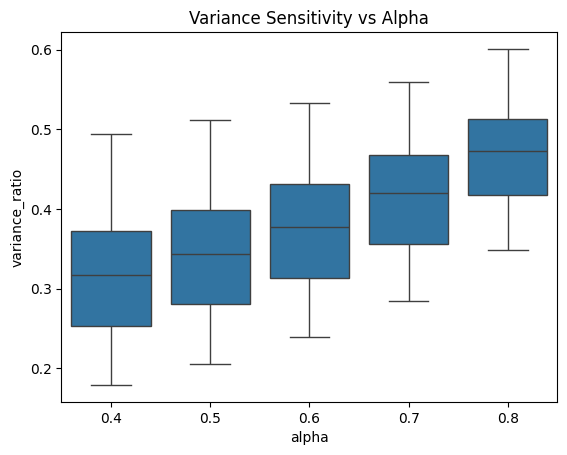

In [116]:
import seaborn as sns

sns.boxplot(
    data=results_df,
    x="alpha",
    y="variance_ratio"
)

plt.title("Variance Sensitivity vs Alpha")
plt.show()


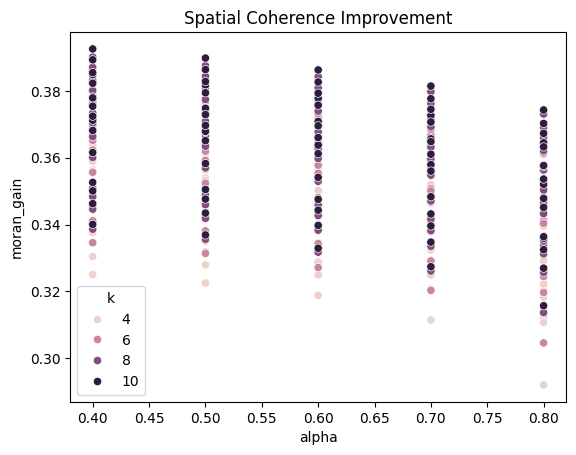

In [117]:
sns.scatterplot(
    data=results_df,
    x="alpha",
    y="moran_gain",
    hue="k"
)

plt.title("Spatial Coherence Improvement")
plt.show()


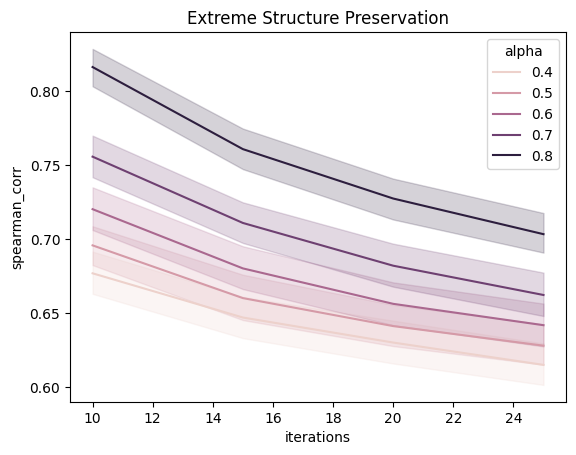

In [118]:
sns.lineplot(
    data=results_df,
    x="iterations",
    y="spearman_corr",
    hue="alpha"
)

plt.title("Extreme Structure Preservation")
plt.show()


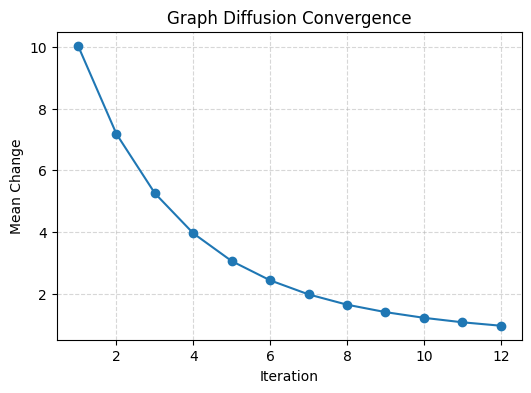

In [122]:
# with best parameters 
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from scipy.spatial import KDTree

# ============================================================
# PARAMETERS (validated)
# ============================================================

alpha = 0.75
iterations = 12
k = 6

# ============================================================
# BUILD GRAPH
# ============================================================

coords = np.vstack([grid_evt.geometry.x, grid_evt.geometry.y]).T
tree = KDTree(coords)

G = nx.Graph()

for i in range(len(coords)):
    G.add_node(i)

for i, p in enumerate(coords):

    dist, idx = tree.query(p, k=k)

    for j in idx[1:]:
        G.add_edge(i, j)

# ============================================================
# INITIAL HAZARD FIELD
# ============================================================

h = grid_evt["rl_100"].values.copy()

changes = []

# ============================================================
# DIFFUSION ITERATIONS
# ============================================================

for _ in range(iterations):

    new_h = h.copy()

    for node in G.nodes:

        neigh = list(G.neighbors(node))
        if len(neigh) == 0:
            continue

        neigh_mean = h[neigh].mean()

        new_h[node] = alpha * h[node] + (1 - alpha) * neigh_mean

    change = np.mean(np.abs(new_h - h))
    changes.append(change)

    h = new_h

# ============================================================
# CONVERGENCE PLOT
# ============================================================

plt.figure(figsize=(6,4))

plt.plot(range(1, iterations+1), changes, marker="o")

plt.title("Graph Diffusion Convergence")
plt.xlabel("Iteration")
plt.ylabel("Mean Change")

plt.grid(True, linestyle="--", alpha=0.5)

plt.show()


In [123]:
import geopandas as gpd
import numpy as np
import networkx as nx
from scipy.spatial import KDTree

# ============================================================
# PARAMETERS (validated from cross-validation)
# ============================================================

k_neighbors = 6
alpha = 0.75
iterations = 12

return_levels = ["rl_10","rl_25","rl_50","rl_100"]

# ============================================================
# LOAD EVT GRID DATA
# ============================================================

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_grid_evt.geojson"
)

coords = np.vstack([
    grid_evt.geometry.x,
    grid_evt.geometry.y
]).T

tree = KDTree(coords)

# ============================================================
# BASELINE: SPATIAL SMOOTHING (IDW)
# ============================================================

print("Computing baseline spatial smoothing...")

for rl in return_levels:

    smoothed = []

    for i, point in enumerate(coords):

        dist, idx = tree.query(point, k=k_neighbors)

        weights = 1 / (dist + 1e-6)
        weights = weights / weights.sum()

        h = grid_evt.iloc[idx][rl].values

        smoothed.append((weights * h).sum())

    grid_evt[f"{rl}_smooth"] = smoothed

# ============================================================
# BUILD SPATIAL GRAPH
# ============================================================

print("Building spatial graph...")

G = nx.Graph()

for i in range(len(coords)):
    G.add_node(i)

for i, point in enumerate(coords):

    dist, idx = tree.query(point, k=k_neighbors)

    for j in idx[1:]:
        G.add_edge(i, j)

# ============================================================
# GRAPH DIFFUSION FUNCTION
# ============================================================

def graph_diffusion(hazard, G, alpha, iterations):

    h = hazard.copy()

    for _ in range(iterations):

        new_h = h.copy()

        for node in G.nodes:

            neighbors = list(G.neighbors(node))

            if len(neighbors) == 0:
                continue

            neighbor_mean = h[neighbors].mean()

            new_h[node] = (
                alpha * h[node] +
                (1 - alpha) * neighbor_mean
            )

        h = new_h

    return h

# ============================================================
# COMPUTE GRAPH DIFFUSED HAZARD FIELDS
# ============================================================

print("Running graph diffusion...")

for rl in return_levels:

    hazard = grid_evt[rl].values

    diffused = graph_diffusion(
        hazard,
        G,
        alpha,
        iterations
    )

    grid_evt[f"{rl}_graphdiff"] = diffused

# ============================================================
# SAVE FINAL DATASET
# ============================================================

output_path = "/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_hazard_fields.geojson"

grid_evt.to_file(
output_path,
driver="GeoJSON"
)

print("--------------------------------------------------")
print("Hazard field generation completed.")
print("Saved to:", output_path)
print("--------------------------------------------------")


Computing baseline spatial smoothing...
Building spatial graph...
Running graph diffusion...
--------------------------------------------------
Hazard field generation completed.
Saved to: /vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_hazard_fields.geojson
--------------------------------------------------


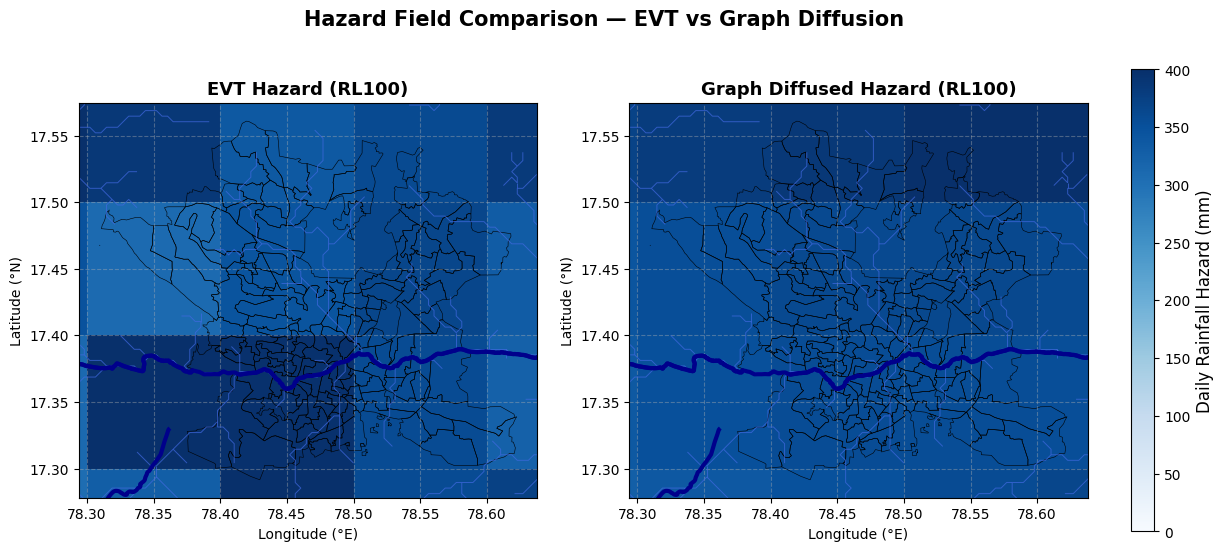

In [124]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

# ============================================================
# LOAD DATA
# ============================================================

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_hazard_fields.geojson"
)

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

rivers = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/hydrorivers_clean.geojson"
).to_crs(epsg=4326)

musi = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/musi.geojson"
).to_crs(epsg=4326)

# ============================================================
# CREATE GRIDS
# ============================================================

grid_evt_p = grid_evt.pivot(index="lat", columns="lon", values="rl_100")
grid_diff_p = grid_evt.pivot(index="lat", columns="lon", values="rl_100_graphdiff")

lats = grid_evt_p.index.values
lons = grid_evt_p.columns.values

vals_evt = grid_evt_p.values
vals_diff = grid_diff_p.values

# ============================================================
# MAP EXTENT
# ============================================================

minx, miny, maxx, maxy = wards.total_bounds

pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)

# ============================================================
# COLOR SCALE
# ============================================================

norm = mpl.colors.Normalize(
    vmin=0,
    vmax=400
)

# ============================================================
# FIGURE
# ============================================================

fig,ax = plt.subplots(1,2,figsize=(14,6))

# ============================================================
# EVT HAZARD
# ============================================================

mesh1 = ax[0].pcolormesh(
    lons,
    lats,
    vals_evt,
    cmap="Blues",
    shading="auto",
    norm=norm,
    zorder=1
)

wards.plot(ax=ax[0], facecolor="none", edgecolor="black", linewidth=0.4)
rivers.plot(ax=ax[0], color="royalblue", linewidth=0.7, alpha=0.7)
musi.plot(ax=ax[0], color="darkblue", linewidth=3)

ax[0].set_xlim(minx-pad_x, maxx+pad_x)
ax[0].set_ylim(miny-pad_y, maxy+pad_y)

ax[0].set_xlabel("Longitude (°E)")
ax[0].set_ylabel("Latitude (°N)")
ax[0].grid(True, linestyle="--", alpha=0.4)

ax[0].set_aspect("equal")
ax[0].set_title("EVT Hazard (RL100)", fontsize=13, weight="bold")

# ============================================================
# GRAPH DIFFUSED HAZARD
# ============================================================

mesh2 = ax[1].pcolormesh(
    lons,
    lats,
    vals_diff,
    cmap="Blues",
    shading="auto",
    norm=norm,
    zorder=1
)

wards.plot(ax=ax[1], facecolor="none", edgecolor="black", linewidth=0.4)
rivers.plot(ax=ax[1], color="royalblue", linewidth=0.7, alpha=0.7)
musi.plot(ax=ax[1], color="darkblue", linewidth=3)

ax[1].set_xlim(minx-pad_x, maxx+pad_x)
ax[1].set_ylim(miny-pad_y, maxy+pad_y)

ax[1].set_xlabel("Longitude (°E)")
ax[1].set_ylabel("Latitude (°N)")
ax[1].grid(True, linestyle="--", alpha=0.4)

ax[1].set_aspect("equal")
ax[1].set_title("Graph Diffused Hazard (RL100)", fontsize=13, weight="bold")

# ============================================================
# COLORBAR
# ============================================================

cbar = fig.colorbar(mesh2, ax=ax, fraction=0.03, pad=0.04)

cbar.set_label(
"Daily Rainfall Hazard (mm)",
fontsize=12
)

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
"Hazard Field Comparison — EVT vs Graph Diffusion",
fontsize=15,
weight="bold"
)

plt.show()


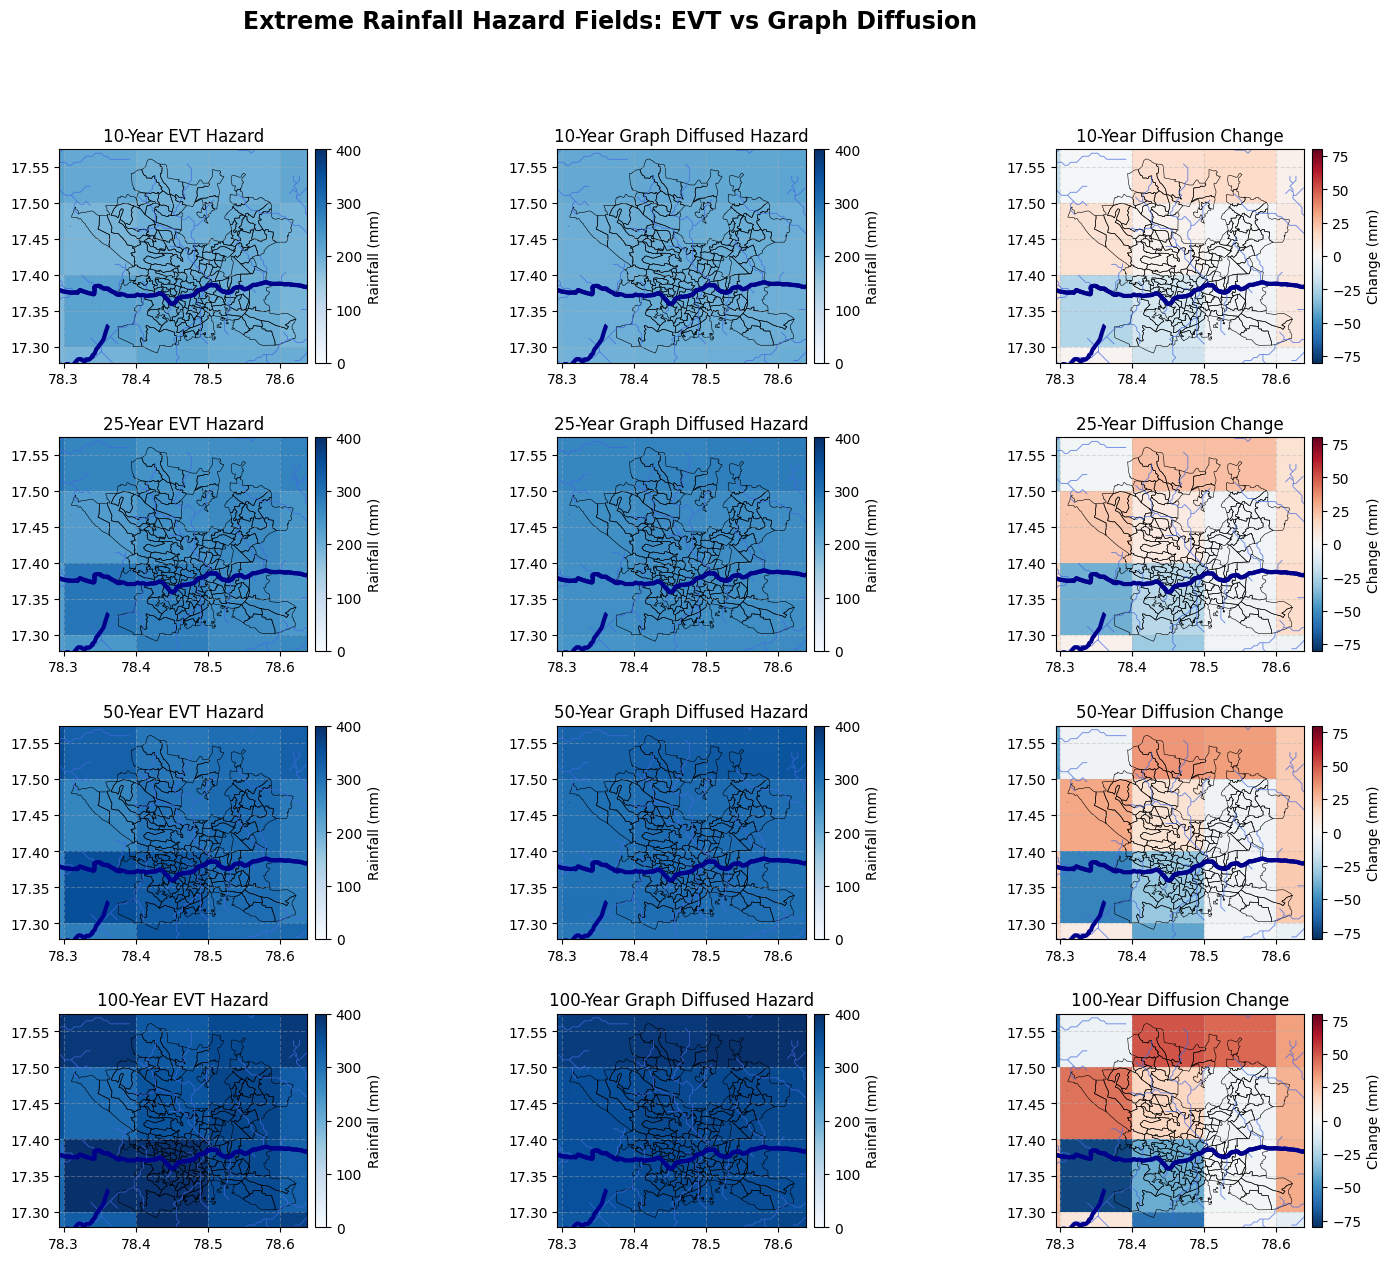

In [125]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np
from matplotlib.gridspec import GridSpec

# ============================================================
# LOAD DATA
# ============================================================

grid_evt = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/hyderabad_hazard_fields.geojson"
)

wards = gpd.read_file(
"/vol/sandeep_storage/Files2/Hydro_Graph/ward_musi_with_roads_hospitals.geojson"
).to_crs(epsg=4326)

rivers = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/hydrorivers_clean.geojson"
).to_crs(epsg=4326)

musi = gpd.read_file(
"/vol/sandeep_storage/Files2/catastrophe/hydrorivers/musi.geojson"
).to_crs(epsg=4326)

# ============================================================
# MAP EXTENT
# ============================================================

minx, miny, maxx, maxy = wards.total_bounds
pad_x = 0.05 * (maxx - minx)
pad_y = 0.05 * (maxy - miny)

# ============================================================
# COLOR SCALES
# ============================================================

hazard_norm = mpl.colors.Normalize(vmin=0, vmax=400)

diff_norm = mpl.colors.TwoSlopeNorm(
    vmin=-80,
    vcenter=0,
    vmax=80
)

# ============================================================
# RETURN LEVELS
# ============================================================

return_levels = ["10","25","50","100"]

# ============================================================
# FIGURE LAYOUT
# ============================================================

fig = plt.figure(figsize=(18,14))

gs = GridSpec(
    4,3,
    wspace=0.25,
    hspace=0.35
)

# ============================================================
# LOOP THROUGH RETURN LEVELS
# ============================================================

for i,rl in enumerate(return_levels):

    ax_evt = fig.add_subplot(gs[i,0])
    ax_graph = fig.add_subplot(gs[i,1])
    ax_diff = fig.add_subplot(gs[i,2])

    evt_grid = grid_evt.pivot(index="lat", columns="lon", values=f"rl_{rl}")
    graph_grid = grid_evt.pivot(index="lat", columns="lon", values=f"rl_{rl}_graphdiff")

    lats = evt_grid.index.values
    lons = evt_grid.columns.values

    vals_evt = evt_grid.values
    vals_graph = graph_grid.values
    vals_diff = vals_graph - vals_evt

    # ========================================================
    # EVT HAZARD
    # ========================================================

    mesh_evt = ax_evt.pcolormesh(
        lons,
        lats,
        vals_evt,
        cmap="Blues",
        shading="auto",
        norm=hazard_norm
    )

    wards.plot(ax=ax_evt, facecolor="none", edgecolor="black", linewidth=0.4)
    rivers.plot(ax=ax_evt, color="royalblue", linewidth=0.7, alpha=0.7)
    musi.plot(ax=ax_evt, color="darkblue", linewidth=3)

    ax_evt.set_xlim(minx-pad_x, maxx+pad_x)
    ax_evt.set_ylim(miny-pad_y, maxy+pad_y)

    ax_evt.set_aspect("equal")
    ax_evt.grid(True, linestyle="--", alpha=0.4)

    ax_evt.set_title(f"{rl}-Year EVT Hazard")

    cbar_evt = fig.colorbar(mesh_evt, ax=ax_evt, fraction=0.045, pad=0.02)
    cbar_evt.set_label("Rainfall (mm)")


    # ========================================================
    # GRAPH DIFFUSED HAZARD
    # ========================================================

    mesh_graph = ax_graph.pcolormesh(
        lons,
        lats,
        vals_graph,
        cmap="Blues",
        shading="auto",
        norm=hazard_norm
    )

    wards.plot(ax=ax_graph, facecolor="none", edgecolor="black", linewidth=0.4)
    rivers.plot(ax=ax_graph, color="royalblue", linewidth=0.7, alpha=0.7)
    musi.plot(ax=ax_graph, color="darkblue", linewidth=3)

    ax_graph.set_xlim(minx-pad_x, maxx+pad_x)
    ax_graph.set_ylim(miny-pad_y, maxy+pad_y)

    ax_graph.set_aspect("equal")
    ax_graph.grid(True, linestyle="--", alpha=0.4)

    ax_graph.set_title(f"{rl}-Year Graph Diffused Hazard")

    cbar_graph = fig.colorbar(mesh_graph, ax=ax_graph, fraction=0.045, pad=0.02)
    cbar_graph.set_label("Rainfall (mm)")


    # ========================================================
    # DIFFUSION DIFFERENCE
    # ========================================================

    mesh_diff = ax_diff.pcolormesh(
        lons,
        lats,
        vals_diff,
        cmap="RdBu_r",
        shading="auto",
        norm=diff_norm
    )

    wards.plot(ax=ax_diff, facecolor="none", edgecolor="black", linewidth=0.4)
    rivers.plot(ax=ax_diff, color="royalblue", linewidth=0.7, alpha=0.7)
    musi.plot(ax=ax_diff, color="darkblue", linewidth=3)

    ax_diff.set_xlim(minx-pad_x, maxx+pad_x)
    ax_diff.set_ylim(miny-pad_y, maxy+pad_y)

    ax_diff.set_aspect("equal")
    ax_diff.grid(True, linestyle="--", alpha=0.4)

    ax_diff.set_title(f"{rl}-Year Diffusion Change")

    cbar_diff = fig.colorbar(mesh_diff, ax=ax_diff, fraction=0.045, pad=0.02)
    cbar_diff.set_label("Change (mm)")

# ============================================================
# TITLE
# ============================================================

fig.suptitle(
"Extreme Rainfall Hazard Fields: EVT vs Graph Diffusion",
fontsize=17,
weight="bold"
)

plt.show()


In [126]:
import libpysal
from esda.moran import Moran

coords = np.vstack([grid_evt.geometry.x, grid_evt.geometry.y]).T

weights = libpysal.weights.KNN.from_array(coords, k=6)

return_levels = ["10","25","50","100"]

for rl in return_levels:

    evt = grid_evt[f"rl_{rl}"]
    graph = grid_evt[f"rl_{rl}_graphdiff"]

    mor_evt = Moran(evt, weights)
    mor_graph = Moran(graph, weights)

    print(f"\n{rl}-year return level")

    print("EVT Moran I:", mor_evt.I)
    print("Graph Diffusion Moran I:", mor_graph.I)
    print("Gain:", mor_graph.I - mor_evt.I)



10-year return level
EVT Moran I: 0.6309051116763821
Graph Diffusion Moran I: 0.95093638547553
Gain: 0.320031273799148

25-year return level
EVT Moran I: 0.6051418608254093
Graph Diffusion Moran I: 0.9458573895735686
Gain: 0.34071552874815925

50-year return level
EVT Moran I: 0.5932525355985367
Graph Diffusion Moran I: 0.9436375135777814
Gain: 0.3503849779792446

100-year return level
EVT Moran I: 0.5846518862496419
Graph Diffusion Moran I: 0.9422373058226852
Gain: 0.35758541957304324


In [127]:
from scipy.stats import spearmanr

for rl in return_levels:

    corr = spearmanr(
        grid_evt[f"rl_{rl}"],
        grid_evt[f"rl_{rl}_graphdiff"]
    ).correlation

    print(f"{rl}-year rank correlation:", corr)


10-year rank correlation: 0.7852561314032852
25-year rank correlation: 0.7706712667816696
50-year rank correlation: 0.7669766744168605
100-year rank correlation: 0.7617370434260857


In [128]:
for rl in return_levels:

    var_evt = np.var(grid_evt[f"rl_{rl}"])
    var_graph = np.var(grid_evt[f"rl_{rl}_graphdiff"])

    print(f"\n{rl}-year")

    print("EVT variance:", var_evt)
    print("Graph variance:", var_graph)
    print("Variance ratio:", var_graph/var_evt)



10-year
EVT variance: 650.1454985993253
Graph variance: 332.8539803946898
Variance ratio: 0.5119684456968341

25-year
EVT variance: 1791.0714812680571
Graph variance: 874.6762483346555
Variance ratio: 0.4883536237846829

50-year
EVT variance: 3642.5394628024187
Graph variance: 1743.609787318002
Variance ratio: 0.4786797247150594

100-year
EVT variance: 7107.430967179921
Graph variance: 3358.2773699783966
Variance ratio: 0.4725022846491171


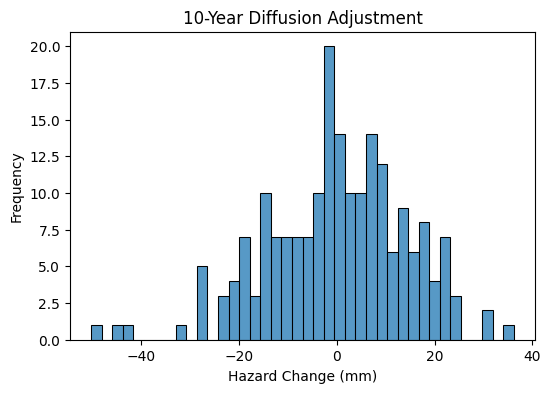

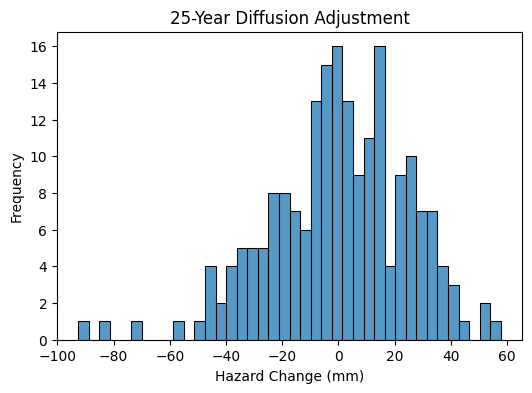

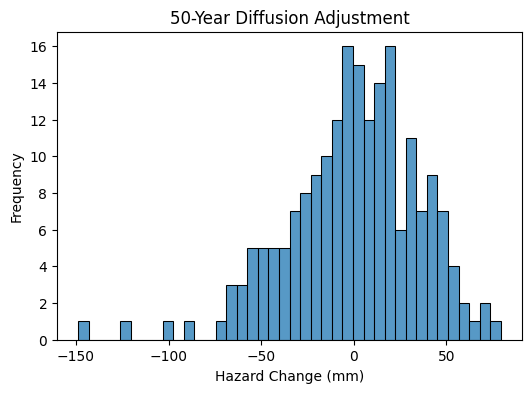

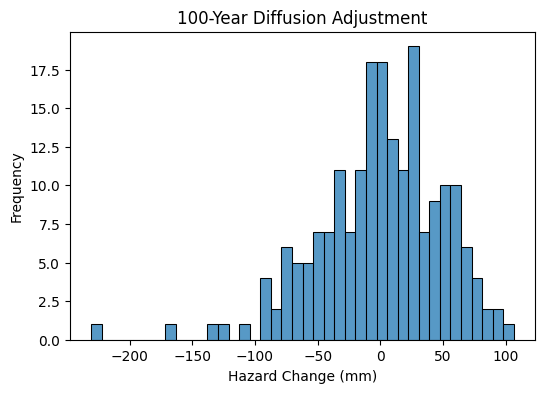

In [129]:
import seaborn as sns
import matplotlib.pyplot as plt

for rl in return_levels:

    diff = (
        grid_evt[f"rl_{rl}_graphdiff"] -
        grid_evt[f"rl_{rl}"]
    )

    plt.figure(figsize=(6,4))

    sns.histplot(diff, bins=40)

    plt.title(f"{rl}-Year Diffusion Adjustment")
    plt.xlabel("Hazard Change (mm)")
    plt.ylabel("Frequency")

    plt.show()


In [130]:
from scipy.spatial import KDTree

tree = KDTree(coords)

k = 6

for rl in return_levels:

    evt = grid_evt[f"rl_{rl}"].values
    graph = grid_evt[f"rl_{rl}_graphdiff"].values

    evt_diff = []
    graph_diff = []

    for i,p in enumerate(coords):

        dist,idx = tree.query(p,k=k)

        evt_diff.append(abs(evt[i] - evt[idx].mean()))
        graph_diff.append(abs(graph[i] - graph[idx].mean()))

    print(f"\n{rl}-year")

    print("EVT neighbor difference:", np.mean(evt_diff))
    print("Graph neighbor difference:", np.mean(graph_diff))



10-year
EVT neighbor difference: 9.614257626944699
Graph neighbor difference: 0.9843501069626618

25-year
EVT neighbor difference: 16.348293962116248
Graph neighbor difference: 1.6605099437955544

50-year
EVT neighbor difference: 23.47607712397962
Graph neighbor difference: 2.373085282412167

100-year
EVT neighbor difference: 32.83061088820687
Graph neighbor difference: 3.3023559337327084


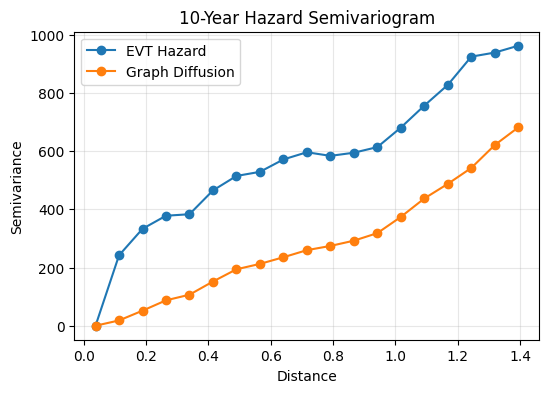

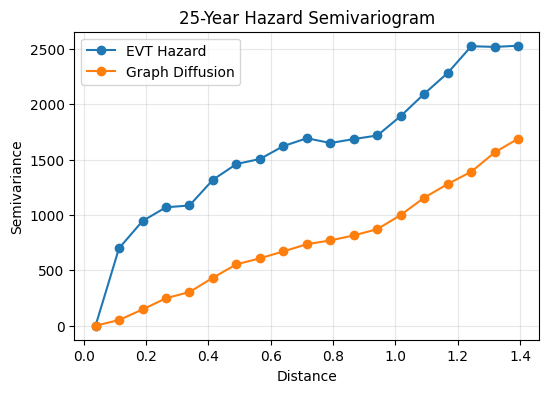

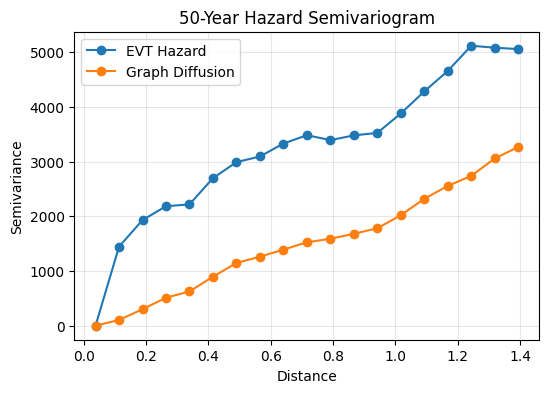

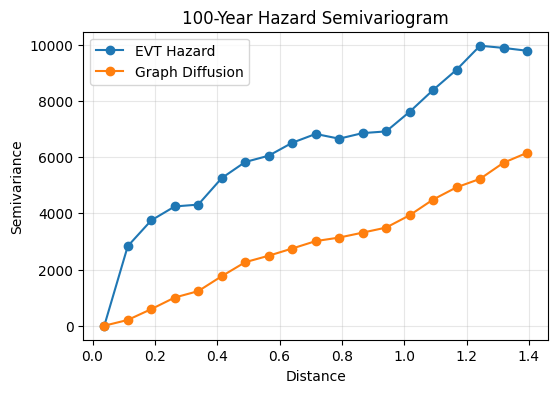

In [131]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

coords = np.vstack([grid_evt.geometry.x, grid_evt.geometry.y]).T

return_levels = ["10","25","50","100"]

# pairwise distances
dist_mat = distance_matrix(coords, coords)

max_dist = np.percentile(dist_mat, 90)

bins = np.linspace(0, max_dist, 20)

for rl in return_levels:

    evt = grid_evt[f"rl_{rl}"].values
    graph = grid_evt[f"rl_{rl}_graphdiff"].values

    gamma_evt = []
    gamma_graph = []
    bin_centers = []

    for i in range(len(bins)-1):

        dmin = bins[i]
        dmax = bins[i+1]

        mask = (dist_mat >= dmin) & (dist_mat < dmax)

        if np.sum(mask) == 0:
            continue

        diff_evt = (evt[:,None] - evt[None,:])**2
        diff_graph = (graph[:,None] - graph[None,:])**2

        gamma_evt.append(0.5*np.mean(diff_evt[mask]))
        gamma_graph.append(0.5*np.mean(diff_graph[mask]))

        bin_centers.append((dmin+dmax)/2)

    plt.figure(figsize=(6,4))

    plt.plot(bin_centers, gamma_evt, label="EVT Hazard", marker="o")
    plt.plot(bin_centers, gamma_graph, label="Graph Diffusion", marker="o")

    plt.xlabel("Distance")
    plt.ylabel("Semivariance")
    plt.title(f"{rl}-Year Hazard Semivariogram")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()


---